# Aprendizaje de Máquina

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Chunga, Juan Miguel (juanmiguel.ch2014@gmail.com)
- Gonzalez, Juan (juan.gonzalez.working@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Carga del dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
body_fat_dataset = pd.read_csv("./dataset/bodyfat.csv")

In [ ]:
# Configuramos el output display con 100 filas
pd.options.display.max_rows = 100
# Configuramos el output display con 100 columnas
pd.options.display.max_columns = 100

## Descripción general del dataset

Para este trabajo final se seleccionó el [Body Fat Prediction](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset) dataset de la plataforma [Kaggle](https://www.kaggle.com/).

Este dataset se caracteriza por tener información correspondiente a las mediciones del porcentaje de grasa corporal de distintas personas, presentada en 252 registros con 15 columnas.

Las columnas son las siguientes:

| Columna | Descripción |
| --- | --- |
| Density | Densidad, determinada a partir del pesaje debajo del agua |
| BodyFat | Porcentaje de grasa corporal, acorde a la [ecuación de Siri](https://www.sciencedirect.com/science/article/pii/S1279770723024442) |
| Age | Edad, medida en años |
| Weight | Peso, en libras |
| Height | Altura, en pulgadas |
| Neck | Circunferencia del cuello, medida en centímetros |
| Chest | Circunferencia del pecho, en centímetros |
| Abdomen | Circunferencia del abdomen, en centímetros |
| Hip | Circunferencia de la cintura, en centímetros |
| Thigh | Circunferencia del muslo, en centímetros |
| Knee | Circunferencia de la rodilla, en centímetros |
| Ankle | Circunferencia del tobillo, en centímetros |
| Bicep | Circunferencia del bicep (extendido), en centímetros |
| Forearm | Circunferencia del antebrazo, en centímetros |
| Wrist | Circunferencia de la muñeca, en centímetros |

## Descripción del problema a resolver

El objetivo de este trabajo práctico consiste en la resolución de un problema de regresión sobre el `Body fat prediction` dataset, más precisamente, sobre la variable `BodyFat`.

*Métricas de evaluación*

- Root Mean Square Error (RMSE)
    - Raíz cuadrada del error cuadrático medio, la utilizaremos ya que se encuentra en la misma `escala` que los datos del dataset, además de que `penaliza` a los errores de predicción más grandes (sensible a outliers).
    - A menor valor, mejor performance tiene el modelo.
    - [Fuente 1](https://www.statisticshowto.com/probability-and-statistics/regression-analysis/rmse-root-mean-square-error/), [Fuente 2](https://dev.to/mondal_sabbha/understanding-mae-mse-and-rmse-key-metrics-in-machine-learning-4la2).
- Mean Absolute Error (MAE)
    - Error absoluto medio, la utilizaremos porque, al igual que RMSE, está en la misma `escala` que el dataset, pero `NO` es sensible a outliers.
    - [Fuente 1](https://www.statisticshowto.com/absolute-error/), [Fuente 2](https://dev.to/mondal_sabbha/understanding-mae-mse-and-rmse-key-metrics-in-machine-learning-4la2).
- R-Squared ($R^{2}$)
    - Representa que tan bueno fue el ajuste del modelo, con un valor entre `0` (el modelo no encuentra relación entre las variables, o *underfitting*) y `1` (el modelo se ajusta perfectamente a los datos, u *overfitting*).
    - [Fuente 1](https://medium.com/@bayramorkunor/r-square-in-machine-learning-a-powerful-tool-for-evaluating-model-performance-f90b43e23d9b), [Fuente 2](https://www.geeksforgeeks.org/machine-learning/ml-r-squared-in-regression-analysis/).

*Enfoque de trabajo*

1. Se comenzará realizando un `Análisis exploratorio del dataset` (EDA), a fin de conocer las dimensiones del mismo, sus columnas, y el tipo de dato y distribución de las mismas.
1. Una vez identificada las columnas, sus tipos de datos y sus distribuciones, se realizará la etapa de `preprocesamiento`:
    1. Comenzaremos realizando el `análisis y tratamiento de nulos`.
    1. Seguiremos con el `análisis y tratamiento de outliers` o datos atípicos.
    1. Una vez tratados los nulos y outliers, se crearán `nuevas features`.
    1. Se `discretizarán las columnas` numéricas continuas, tanto columnas del dataset original como las columnas creadas en pasos posteriores del `preprocesamiento`.
    1. Una vez discretizadas las variables, se procederá a `codificarlas`.
    1. Se realizará un escalado de todas las features numéricas del dataset.
    1. Se realizará un estudio de reducción de la dimensionalidad del dataset, a fin de saber si es conveniente quitar features del mismo.
1. Una vez procesado el dataset, se procederá a entrenar, evaluar y comparar diversos modelos de Machine Learning, tales como:
    1. Regresión por KNN, utilizando [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html).
    1. Regresión mediante SVM, utilizando [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html).
    1. Árboles de regresión, utilizando [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html).
    1. Regresión por Random Forest, utilizando [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).
    1. Gradiant-boosting Regression tree basado en histogramas, utilizando [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html).
    1. XGBoost para regresión, utilizando [XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html).
1. Finalmente, se seleccionará al mejor modelo de todos los estudiados en el paso anterior, y se escribirá la conclusión del trabajo.

## Paso 1 - Análisis exploratorio del dataset

### Paso 1.1 - Análisis de columnas del dataset

Comenzamos analizando la dimensión del dataset, la cual se observa que es de $252$ filas por $15$ columnas.

In [226]:
body_fat_dataset.shape

(252, 15)

En la siguiente celda se muestran las primeras 5 filas del dataset, para tener una primera visión de las mismas.

In [227]:
body_fat_dataset.head(5)

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


Mostramos mediante el método `describe` algunas características de cada columna, tales como la cantidad total (*count*), media (*mean*), desvío estandar (*std*), valores mínimos y máximos (*min* y *max*), y los percentiles *25%*, *50%* y *75%*.

In [228]:
body_fat_dataset.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


A continuación se definen una serie de funciones que nos permitirán analizar ciertas métricas de cada columna:

In [229]:
# Devuelve métricas relacionadas al rango Intercuartil
def metricas_iqr(data):
    Q1 = data.quantile(0.25)
    Q2 = data.quantile(0.50)
    Q3 = data.quantile(0.75)

    IQR = Q3 - Q1
    min_iqr = Q1 - 1.5*IQR
    max_iqr = Q3 + 1.5*IQR

    return Q1, Q2, Q3, IQR, min_iqr, max_iqr

In [230]:
# Devuelve varias métricas de una columna
def obtener_metricas_columna(dataset, col):
    data = dataset[col]

    skewness = data.skew()
    kurtosis = data.kurt()
    media = data.mean()
    moda = data.mode()[0]
    mediana = data.median()
    var = data.std()
    min = data.min()
    max = data.max()
    nunique = data.nunique()
    mask_cant_ceros = data == 0
    cant_ceros = len(dataset[mask_cant_ceros])

    Q1, _, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    return media, moda, mediana, var, min, max, nunique, cant_ceros, Q1, Q3, IQR, min_iqr, max_iqr, skewness, kurtosis

In [231]:
def mostrar_metricas_dataset(dataset):
    print(f"\tColumna\t|\tMedia\t\t\t|\tModa\t|\tMediana\t|\tVarianza\t\t|\tMínimo\t|\tMáximo\t|\tCant. Únicos\t|\tCant. ceros\t|\tSkewness\t\t|\tKurtosis\t\t|")
    for col in dataset.columns:
        media, moda, mediana, var, min, max, nunique, cant_ceros, _, _, _, _, _, skewness, kurtosis = obtener_metricas_columna(dataset=dataset, col=col)

        print(f"\t{col}\t|\t{media}\t|\t{moda}\t|\t{mediana}\t|\t{var}\t|\t{min}\t|\t{max}\t|\t{nunique}\t\t|\t{cant_ceros}\t\t|\t{skewness}\t|\t{kurtosis}\t|")

En la siguiente tabla se pueden observar otras métricas que se calcularon sobre cada columna, tales como:

- Cant. únicos: muestra la cantidad de valores únicos en cada columna. Se recuerda que hay 252 registros totales.
- Cant. ceros: muestra la cantidad de registros con valor cero en cada columna. En todo el dataset hay un solo cero, y corresponde a un registro con `BodyFat` cero.
- `Skewness`: indica si la distribución de una variable presenta asimetría o no.
    - Un valor positivo indica asimetría a derecha.
    - Un valor negativo indica asimetría a izquierda.
    - Se calcula con la función [Skew](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.skew.html) de pandas.
- `Kurtosis`: describe la forma de una distribución de una variable, en particular, su cola o su pico en relación con una distribución Normal.
    - Se calcula con la función [kurt](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.kurt.html#pandas-dataframe-kurt) de pandas, la cual usa la definición de Fisher (kurtosis de una Normal = 0).
    - Un valor positivo indica una distribución con colas más pesadas y un pico más pronunciado que una Normal (leptocúrtica). En algunos casos, las colas pesadas pueden indicar presencia de outliers.
    - Un valor negativo indica una distribución con colas más ligeras y una forma más plana que una Normal (platicúrtica).

| Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
| BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
| Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
| Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
| Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
| Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
| Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136.2	|	174		|	0		|	0.6815557089086869	|	0.9872822206849676	|
| Abdomen	|	92.55595238095238	|	88.7	|	90.95	|	10.783076801381705	|	69.4	|	148.1	|	185		|	0		|	0.838417893390718	|	2.2488237551253754	|
| Hip	|	99.9047619047619	|	98.3	|	99.3	|	7.164057666842289	|	85.0	|	147.7	|	152		|	0		|	1.4971273119966988	|	7.4713521085780314	|
| Thigh	|	59.405952380952385	|	58.9	|	59.0	|	5.249952028401044	|	47.2	|	87.3	|	139		|	0		|	0.8212095695704776	|	2.665714462785864	|
| Knee	|	38.59047619047619	|	39.0	|	38.5	|	2.411804587018756	|	33.0	|	49.1	|	90		|	0		|	0.5167439948759139	|	1.0615358688338015	|
| Ankle	|	23.10238095238095	|	22.0	|	22.8	|	1.6948933981786372	|	19.1	|	33.9	|	61		|	0		|	2.255134289967066	|	11.945194424674785	|
| Biceps	|	32.2734126984127	|	30.5	|	32.05	|	3.0212737512508645	|	24.8	|	45.0	|	104		|	0		|	0.28552999037686816	|	0.49849833584912107	|
| Forearm	|	28.663888888888895	|	27.3	|	28.7	|	2.0206911650269284	|	21.0	|	34.9	|	77		|	0		|	-0.21933277506022672	|	0.8663094115243686	|
| Wrist	|	18.229761904761904	|	18.8	|	18.3	|	0.9335849289587035	|	15.8	|	21.4	|	44		|	0		|	0.28161390690959204	|	0.39567752094226005	|

In [232]:
mostrar_metricas_dataset(body_fat_dataset)

	Columna	|	Media			|	Moda	|	Mediana	|	Varianza		|	Mínimo	|	Máximo	|	Cant. Únicos	|	Cant. ceros	|	Skewness		|	Kurtosis		|
	Density	|	1.0555738095238094	|	1.061	|	1.0549	|	0.019031434171520773	|	0.995	|	1.1089	|	218		|	0		|	-0.020175732162877553	|	-0.3096191237706498	|
	BodyFat	|	19.150793650793652	|	20.4	|	19.2	|	8.368740413029707	|	0.0	|	47.5	|	176		|	1		|	0.14635310763344916	|	-0.3338113932133209	|
	Age	|	44.88492063492063	|	40	|	43.0	|	12.602039722717864	|	22	|	81	|	51		|	0		|	0.2835210972594456	|	-0.4164409142706198	|
	Weight	|	178.92440476190475	|	152.25	|	176.5	|	29.38915988536906	|	118.5	|	363.15	|	197		|	0		|	1.205262933190293	|	5.269513616992537	|
	Height	|	70.14880952380952	|	71.5	|	70.0	|	3.6628557876803174	|	29.5	|	77.75	|	48		|	0		|	-5.384986543608024	|	59.54430208610579	|
	Neck	|	37.992063492063494	|	38.5	|	38.0	|	2.430913234019508	|	31.1	|	51.2	|	90		|	0		|	0.5526199393706229	|	2.7196150888425112	|
	Chest	|	100.82420634920635	|	99.1	|	99.65	|	8.43047553192002	|	79.3	|	136

A continuación se grafican los histogramas correspondientes a las variables del dataset.

In [233]:
def plot_histogramas(data, columns, figsize=(5,5), kde=True, ncols=3, colores = ["gray", "blue", "red"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.histplot(data[col], kde=kde, ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])
    
    plt.tight_layout()
    plt.show()

    return

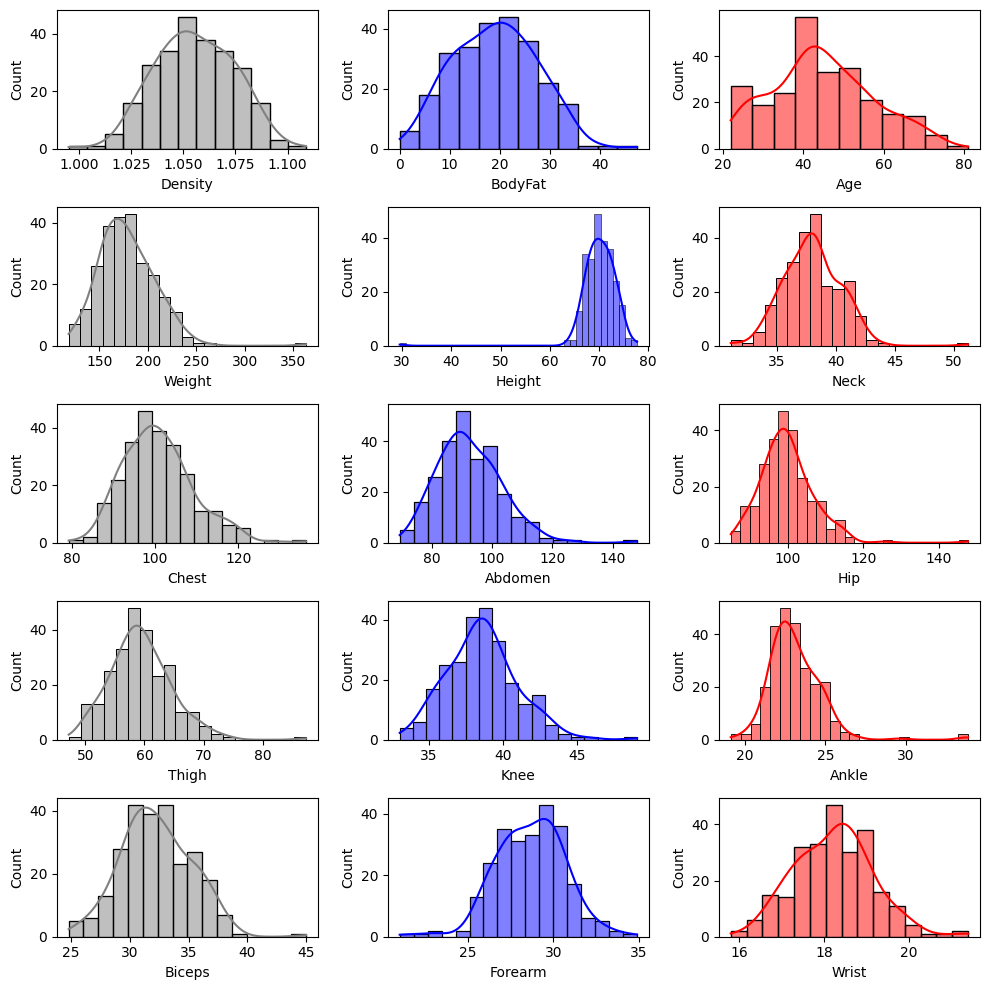

In [234]:
plot_histogramas(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

En alguno de estos gráficos se puede observar características calculadas sobre las variables.

Por ejemplo, las variables `Height`, `Hip` y `Ankle` tienen colas pesadas, lo cual se debe a su valores calculados de *Kurtosis* ($59.5$, $7.47$ y $11.9$ respectivamente).
También se observan asimetrías, tal como indican los valores de Skewness. Por ejemplo, `Height` tiene un valor de $-5.38$, lo cual explica su asimetría a izquierda.

### Paso 1.2 - Análisis de nulos

En esta sección se procede a realizar un análisis de datos faltantes.

Su tratamiento se realizará en secciones posteriores, una vez realizado el split del dataset en *train* y *test*.

Mediante el método `info` obtenemos otras características de las columnas, tales como la cantidad de datos no nulos (*Non-null count*) y el tipo de dato (*Dtype*).

Se observa lo siguiente:

- Ninguna columna tiene valores nulos.
- Todas las columnas son numéricas continuas (*float64*), a excepción de la columna `Age` (edad), que es numérica discreta (*int64*).

In [235]:
body_fat_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


Si bien el método `info` indica que no hay datos nulos, validamos esto de la siguiente manera:

In [236]:
body_fat_dataset.isnull().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Si bien pandas se encarga de tratar los *Null*/*None* como *NaN* (más info [aquí](https://medium.com/@allenhuang1996/whats-the-difference-between-null-and-nan-in-python-a1af20d523ce)), se procede a hacer el análisis de la siguiente manera:

In [237]:
body_fat_dataset.isna().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

Como el dataset contiene información correspondiente a distintas mediciones, también consideraremos nulos a aquellos registros que tengan columnas con valores ceros.

A continuación, se observa el único registro con columnas con valores ceros. En este caso corresponde al registro número 181, y el valor en cero es la columna `BodyFat`.

In [238]:
for col in body_fat_dataset.columns:
    mascara = body_fat_dataset[col] == 0
    data_ceros = body_fat_dataset[mascara]
    cant_ceros = len(data_ceros)

    if cant_ceros > 0:
        print(data_ceros)

     Density  BodyFat  Age  Weight  Height  Neck  Chest  Abdomen   Hip  Thigh  \
181   1.1089      0.0   40   118.5    68.0  33.8   79.3     69.4  85.0   47.2   

     Knee  Ankle  Biceps  Forearm  Wrist  
181  33.5   20.2    27.7     24.6   16.5  


La conclusión de esta sección dedicada al análisis de nulos es que el dataset prácticamente no tiene valores faltantes, a excepción de un solo registro con valor de `BodyFat` en cero.

El tratamiento de este registro se realizará en secciones posteriores, luego de realizar el split en *train* y *test*.

### Paso 1.3 - Análisis de outliers

En esta sección se realizará un análisis de outliers para el dataset de `Body Fat prediction`.

En caso de encontrar outliers, se tratará a estos una vez realizado el split del dataset original en *train* y *test*.

In [239]:
def calcular_cantidad_outliers(dataset, col):
    data = dataset[col]
    Q1, Q2, Q3, IQR, min_iqr, max_iqr = metricas_iqr(data)

    mascara_min_iqr = data < min_iqr
    mascara_max_iqr = data > max_iqr

    cant_outliers_izq = len(dataset[mascara_min_iqr])
    cant_outliers_der = len(dataset[mascara_max_iqr])
    total_outliers = cant_outliers_izq + cant_outliers_der

    return total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr

Se procede a realizar un análisis de outliers de manera cuantitativa, utilizando el rango intercuartil.

El rango intercuartil se define como la diferencia del cuartil tres (75% de los datos) con el cuartil uno (25% de los datos), es decir $IQR = Q3 - Q1$.

Se consideran outliers a:

- Valores menores a $Q1 - 1.5 * IQR$ (los llamaremos outliers a izquierda).
- Valores mayores a $Q3 + 1.5 * IQR$ (los llamaremos outliers a derecha).

En la siguiente tabla se observan los resultados del análisis cuantitativo de outliers para el dataset de `Body Fat prediction`.

La variable con mayor cantidad de outliers es `Forearm`, la cual tiene $5$ outliers.

|	Columna	|Total de outliers|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
| --- |--- |--- |--- |--- |--- |--- |--- |--- |
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|	1.2	|	15.8	|	20.6	|

In [240]:
print("|\tColumna\t|\tTotal de outliers\t|\tOutliers a izquierda\t|\tOutliers a derecha\t|\tQ1\t|\tQ3\t|\tIQR\t|\tQ1-1.5*IQR\t|\tQ3+1.5*IQR\t|")
for col in body_fat_dataset.columns:
    total_outliers, cant_outliers_izq, cant_outliers_der, Q1, Q2, Q3, IQR, min_iqr, max_iqr = calcular_cantidad_outliers(body_fat_dataset, col)

    print(f"|\t{col}\t|\t{total_outliers}\t|\t{cant_outliers_izq}\t|\t{cant_outliers_der}\t|\t{np.round(Q1, 2)}\t|\t{np.round(Q3, 2)}\t|\t{np.round(IQR, 2)}\t|\t{np.round(min_iqr, 2)}\t|\t{np.round(max_iqr, 2)}\t|")


|	Columna	|	Total de outliers	|	Outliers a izquierda	|	Outliers a derecha	|	Q1	|	Q3	|	IQR	|	Q1-1.5*IQR	|	Q3+1.5*IQR	|
|	Density	|	1	|	1	|	0	|	1.04	|	1.07	|	0.03	|	1.0	|	1.11	|
|	BodyFat	|	1	|	0	|	1	|	12.48	|	25.3	|	12.82	|	-6.76	|	44.54	|
|	Age	|	0	|	0	|	0	|	35.75	|	54.0	|	18.25	|	8.38	|	81.38	|
|	Weight	|	2	|	0	|	2	|	159.0	|	197.0	|	38.0	|	102.0	|	254.0	|
|	Height	|	1	|	1	|	0	|	68.25	|	72.25	|	4.0	|	62.25	|	78.25	|
|	Neck	|	3	|	2	|	1	|	36.4	|	39.42	|	3.02	|	31.86	|	43.96	|
|	Chest	|	2	|	0	|	2	|	94.35	|	105.38	|	11.02	|	77.81	|	121.91	|
|	Abdomen	|	3	|	0	|	3	|	84.57	|	99.32	|	14.75	|	62.45	|	121.45	|
|	Hip	|	3	|	0	|	3	|	95.5	|	103.52	|	8.03	|	83.46	|	115.56	|
|	Thigh	|	4	|	0	|	4	|	56.0	|	62.35	|	6.35	|	46.48	|	71.87	|
|	Knee	|	3	|	0	|	3	|	36.98	|	39.92	|	2.95	|	32.55	|	44.35	|
|	Ankle	|	3	|	0	|	3	|	22.0	|	24.0	|	2.0	|	19.0	|	27.0	|
|	Biceps	|	1	|	0	|	1	|	30.2	|	34.32	|	4.12	|	24.01	|	40.51	|
|	Forearm	|	5	|	4	|	1	|	27.3	|	30.0	|	2.7	|	23.25	|	34.05	|
|	Wrist	|	4	|	1	|	3	|	17.6	|	18.8	|

A continuación se crea una función que permite graficar para cada variable un Boxplot.

Esto permite observar gráficamente a los outliers de cada variable.

In [241]:
def plot_boxplot(data, columns, figsize=(5,5), ncols=3, colores = ["gray", "lightblue", "green"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    for i, col in enumerate(columns):
        sns.boxplot(x=data[col], ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])

        axes[math.floor(i/ncols), i%ncols].set_xlabel(col)
        axes[math.floor(i/ncols), i%ncols].set_title(f"Boxplot para {col}")
    
    plt.tight_layout()
    plt.show()

    return

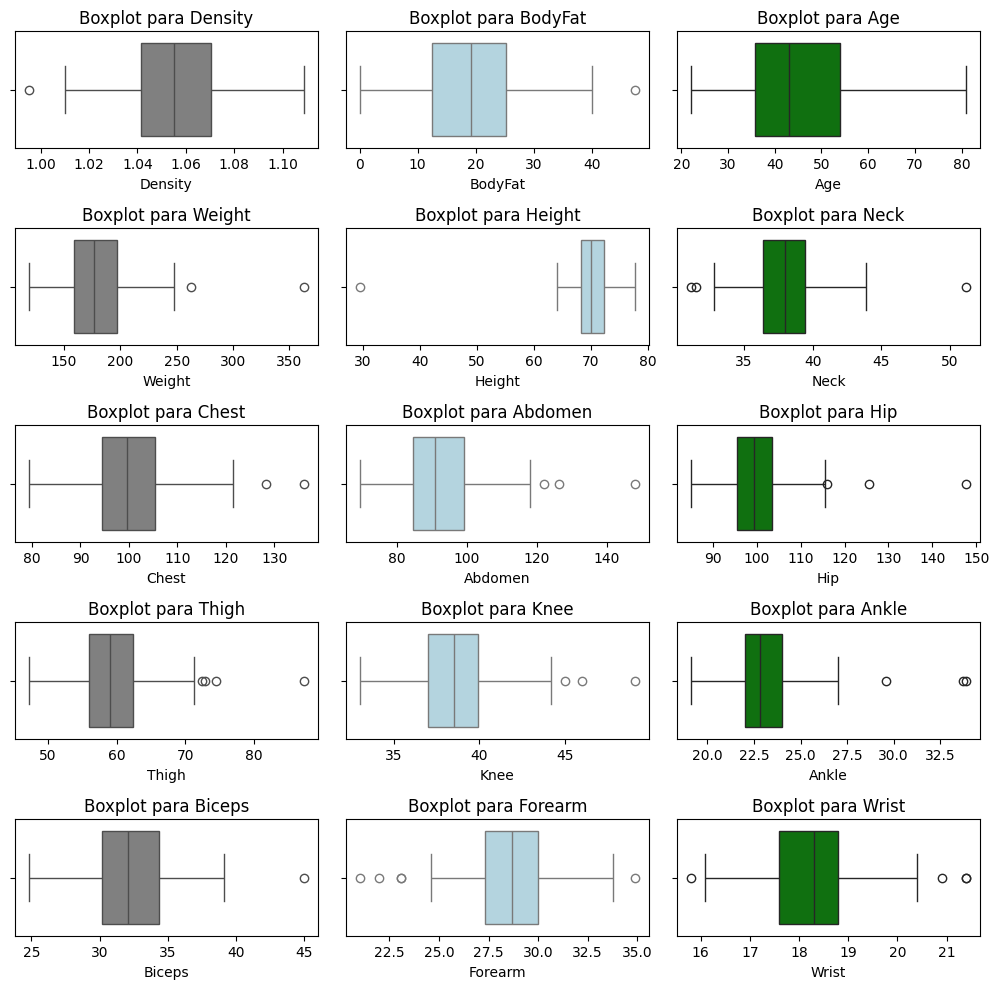

In [242]:
plot_boxplot(body_fat_dataset, body_fat_dataset.columns, figsize=(10,10))

Como conclusión de esta sección podemos decir que, a excepción de `Age`, todas las variables presentan outliers en el dataset.

El tratamiento de estos se realizará en secciones posteriores, una vez se haya realizado el split en *Train* y *Test*.

### Paso 1.4 - Análisis de relación entre variable target y el resto de las variables

A continuación se grafican las variables del dataset contra la variable target `BodyFat`.

In [243]:
def plot_scatterplot(data, columns, ycol, figsize=(5,5), ncols=3, colores = ["gray", "lightblue", "green"]):
    nrows = math.floor(len(columns)/ncols)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    
    columns = columns.drop(ycol)

    for i, col in enumerate(columns):
        sns.scatterplot(data=data, x=col, y=ycol, ax=axes[math.floor(i/ncols), i%ncols], color=colores[i%ncols])

        axes[math.floor(i/ncols), i%ncols].set_xlabel(col)
        axes[math.floor(i/ncols), i%ncols].set_ylabel(ycol)
        axes[math.floor(i/ncols), i%ncols].set_title(f"{ycol} en función de {col}")
    
    plt.tight_layout()
    plt.show()

    return

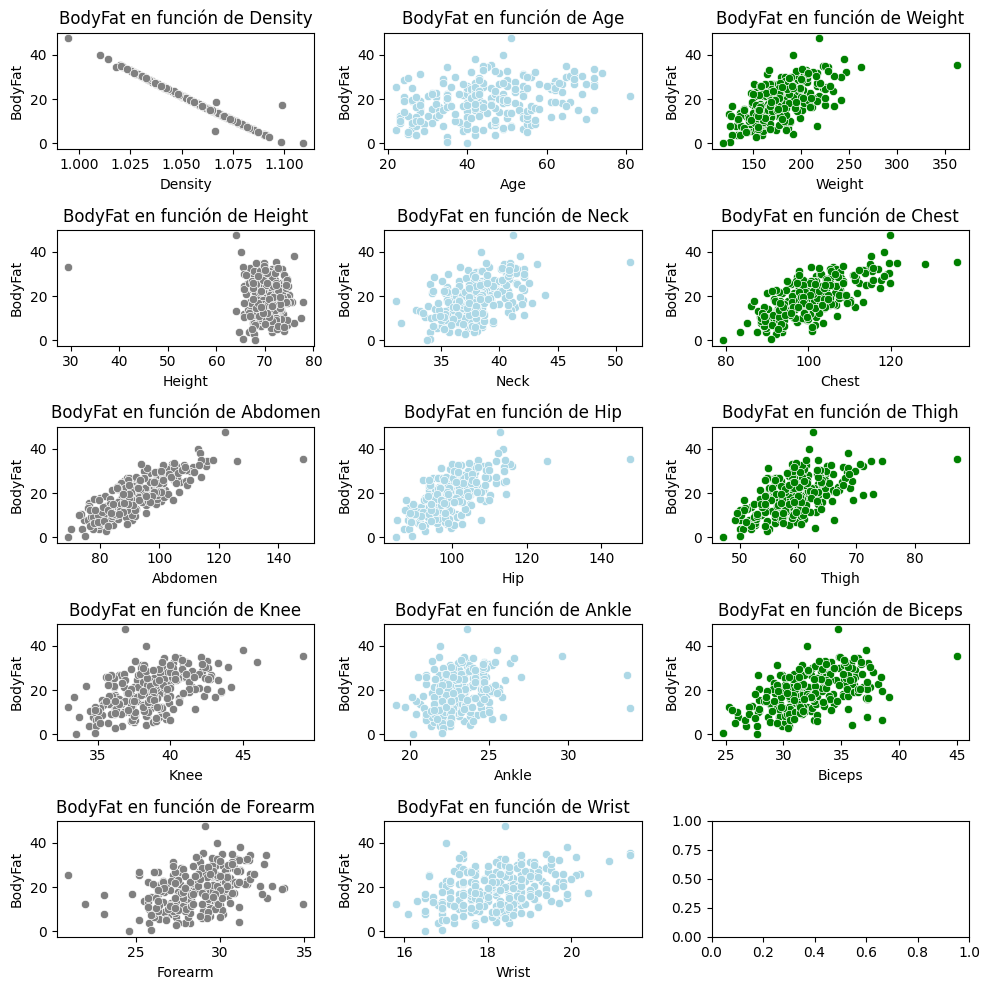

In [244]:
plot_scatterplot(data=body_fat_dataset, columns=body_fat_dataset.columns, ycol="BodyFat", figsize=(10,10))

En el gráfico anterior se puede observar que existe cierta correlación (inversa) entre las variables `BodyFat` y `Density`, lo cual corresponde a lo dicho en la [sección de more details del dataset](https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset).

Otras variables con las que `BodyFat` tiene cierta correlación (por lo que se ve en el gráfico) son:

- `Weight`
- `Abdomen`
- `Chest`
- `Biceps`

Para tener mayor certeza sobre lo dicho anteriormente, se procede a calcular la correlación entre las variables y a realizar un gráfico de las mismas:

In [245]:
# Source: https://seaborn.pydata.org/examples/many_pairwise_correlations.html
def plot_correlaciones(data):
    corr = data.corr()

    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Set up the matplotlib figure
    f, ax = plt.subplots(figsize=(11, 9))

    # Generate a custom diverging colormap
    cmap = sns.diverging_palette(230, 20, as_cmap=True)

    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5}, annot=True)

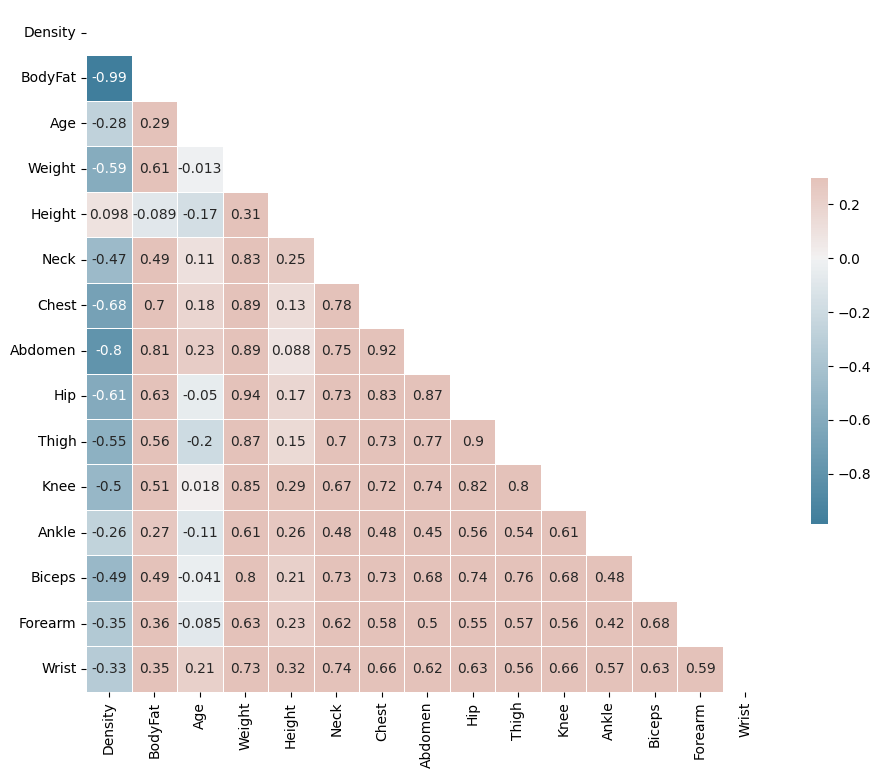

In [246]:
plot_correlaciones(body_fat_dataset)

In [247]:
def obtener_columnas_correlacionadas(dataset, target_col, bounds=[-0.75,0.75]):
    if len(bounds) != 2:
        bounds=[-0.75,0.75]
        print("Atención: `bounds` solo puede tener dos valores. Se sobrescribe con [-0.75,0.75].")

    correlations = dataset.corr()
    corr_target = correlations[target_col]
    mask_upper_bound = corr_target >= bounds[1]
    mask_lower_bound = corr_target <= bounds[0]

    cols_upper_bound = corr_target[mask_upper_bound].index.tolist()
    cols_lower_bound = corr_target[mask_lower_bound].index.tolist()

    return cols_lower_bound, cols_upper_bound

In [248]:
lower, upper = obtener_columnas_correlacionadas(body_fat_dataset, "BodyFat")

print(f"BodyFat: columnas con correlación negativa: {lower}")
print(f"BodyFat: columnas con correlación positiva: {upper}")

BodyFat: columnas con correlación negativa: ['Density']
BodyFat: columnas con correlación positiva: ['BodyFat', 'Abdomen']


Se realizaron un gráfico (heatmap) y un análisis del valor numérico de las correlaciones entre las variables del dataset y `BodyFat`, encontrando que:
- Tiene una correlación negativa con `Density` ($-0.99$)
- Tiene una correlación positiva con `Abdomen` ($0.81$)

Cabe aclarar que se definieron los umbrales de $-0.75$ y $0.75$ para seleccionar las correlaciones de interés.

Los resultados de este análisis serán útiles en pasos posteriores, cuando se busque reducir la dimensionalidad del dataset.

## Paso 2 - Split del dataset

Con el fin de evitar que suceda un [data leakage](https://www.kaggle.com/code/alexisbcook/data-leakage) a la hora de tratar nulos, outliers y realizar operación de *feature engineering* es fundamental realizar un split del dataset en *train* y *test*.

In [249]:
target = "BodyFat"
test_size = 0.3
random_state = 323123

In [250]:
X_train, X_test, y_train, y_test = train_test_split(
    body_fat_dataset.drop(columns=target),
    body_fat_dataset[target],
    random_state=random_state,
    test_size=test_size)

In [251]:
X_train.shape

(176, 14)

In [252]:
X_test.shape

(76, 14)

In [253]:
y_train.shape

(176,)

In [254]:
y_test.shape

(76,)

El dataset de *train* quedó conformado por 176 filas y 14 columnas, mientras que el de *test* se conforma de 76 filas y 14 columnas.

## Paso 3 - Tratamiento de nulos

Al realizar un análisis de nulos en el `Paso 1.2` se encontró que hay solamente un registro con valor nulo, más precisamente, un registro con valor de `BodyFat` igual a cero.

El tratamiento de este valor se realizará de la siguiente manera:

1. Dado a que `BodyFat` es la variable target, y a que en el `Paso 2` se la dividió en *train* y *test*, debemos primero localizar en que subconjunto se encuentra este registro.
1. Una vez localizado, se realizarán las siguientes imputaciones:
    1. Imputación por `Media`
    1. Imputación por `Mediana`
    1. Imputación por `Moda`
    1. **NOTA**: estas métricas se obtendrán del dataset de *train*, para evitar data leakage, y se aplicarán sobre el subconjunto correspondiente.
1. Se compararán los resultados de imputaciones, con el fin de seleccionar aquel que menos altere la distribución de la variable target en el subconjunto analizado.
    1. **NOTA**: debido a que se trata de un solo registro a imputar, podemos decir, a priori, que no habrán alteraciones grandes en la distribución de la variable.

### Paso 3.1 - Identificación del registro con valor cero

A continuación se muestra el código necesario para identificar dónde se encuentra el registro a imputar.

Éste está en el subconjunto de *train*.

In [255]:
mask_body_fat_cero_train = y_train == 0.0
mask_body_fat_cero_test = y_test == 0.0

print(f"""Cantidad de registros iguales a cero
    Train:  {len(y_train[mask_body_fat_cero_train])}
    Test:   {len(y_test[mask_body_fat_cero_test])}
    """)

Cantidad de registros iguales a cero
    Train:  1
    Test:   0
    


### Paso 3.2 - Imputación del registro con valor cero

Comenzamos calculando la `media`, `mediana` y `moda` del subconjunto de *train* de la variable *target*.

In [256]:
y_train_mean = y_train.mean()
y_train_median = y_train.median()
y_train_mode = y_train.mode()[0]

Los valores obtenidos son:

- `Media`: $18.662$
- `Mediana`: $18.65$
- `Moda`: $20.4$

In [257]:
print(f"""Body Fat (y_train):
    Media:  {np.round(y_train_mean, 3)}
    Median: {np.round(y_train_median, 3)}
    Mode:   {np.round(y_train_mode, 3)}
""")

Body Fat (y_train):
    Media:  18.662
    Median: 18.65
    Mode:   20.4



Creamos una copia de `y_train` para realizar las imputaciones por separado.

In [258]:
y_train_mean_imputed = y_train.copy().replace(0, y_train_mean)
y_train_median_imputed = y_train.copy().replace(0, y_train_median)
y_train_mode_imputed = y_train.copy().replace(0, y_train_mode)

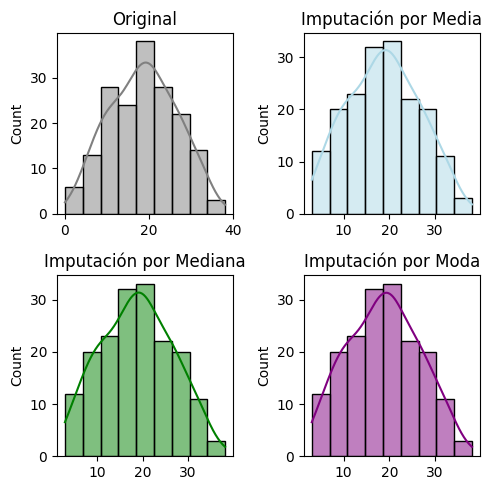

In [259]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5,5))
colores = ["gray", "lightblue", "green", "purple"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Imputación por Moda"]

sns.histplot(y_train, kde=True, ax=axes[0, 0], color=colores[0])
sns.histplot(y_train_mean_imputed, kde=True, ax=axes[0, 1], color=colores[1])
sns.histplot(y_train_median_imputed, kde=True, ax=axes[1, 0], color=colores[2])
sns.histplot(y_train_mode_imputed, kde=True, ax=axes[1, 1], color=colores[3])

for i in range (2):
    for j in range(2):
        axes[i, j].set_xlabel("")
        axes[i, j].set_title(titulos[i*2+j])

plt.tight_layout()
plt.show()

A partir de los gráficos realizados podemos decir que las imputaciones realizadas si cambian la distribución original, entre ellas parecería no haber diferencias.

Para que no haya dudas, se calculas las siguientes métricas de cada distribución:

| Métrica	| Imputación por Media | Imputación por Mediana | Imputación por Moda |
| --- | --- | --- | --- |
|	Cantidad  |  176	|  176	|	 176	|
|	Media  |   18.767966	|   18.767898	|	  18.777841	|
|	Desvío   |    7.853643	|    7.853644	|	   7.854601	|
|	Mínimo    |    3.0	|    3.0	|	   3.0	|
|	25%    |   12.45	|   12.45	|	  12.45	|
|	50%    |   18.730966	|   18.725	|	  18.95	|
|	75%    |   24.825	|   24.825	|	  24.825	|
|	Máximo   |   38.1	|   38.1	|	  38.1	|

Como se puede observar en el gráfico, las tres distribuciones son muy similares en términos de Media (la diferencia es a partir del segundo decimal), Desvío (diferencia a partir del tercer decimal) y Mediana (50% - todas cercanas a 18-19). El resto de los valores son iguales.

In [260]:
y_train_mean_imputed.describe()

count    176.000000
mean      18.767966
std        7.853643
min        3.000000
25%       12.450000
50%       18.730966
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

In [261]:
y_train_median_imputed.describe()

count    176.000000
mean      18.767898
std        7.853644
min        3.000000
25%       12.450000
50%       18.725000
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

In [262]:
y_train_mode_imputed.describe()

count    176.000000
mean      18.777841
std        7.854601
min        3.000000
25%       12.450000
50%       18.950000
75%       24.825000
max       38.100000
Name: BodyFat, dtype: float64

Ya hecho el análisis, se opta por imputar por mediana, ya que es el valor menos sensible a los outliers.

In [263]:
y_train = y_train_median_imputed

## Paso 4 - Tratamiento de outliers

En el análisis de outliers realizado en el `Paso 1.3` se encontró que todas las variables salvo `Age` tienen outliers.

Para tratarlos, se realizará un procedimiento similar al tratamiento de nulos:

1. A partir del dataset de *train*, se definirá el rango intercuartil de cada variable.
1. Se identificarán a los outliers a partir del IQR, tanto en *train* como en *test*.
1. Se imputarán los outliers de ambos subconjuntos a partir de métricas obtenidas en el dataset de *train*:
    1. `Media`.
    1. `Mediana`.
1. Se aplicarán transformaciones sobre las columnas originales:
    1. `Transformación logarítmica`.
    1. `Transformación por raíz cuadrada`.
    1. `Transformación Boxcox`.
1. Se compararán las nuevas distribuciones de cada variable, y se elegirá la mejor para cada columna.

### Paso 4.1 - Tratamiento de outliers mediante técnicas de imputación y transformación

In [264]:
# Generamos copias del dataset de train, para no modificar al original
X_train_mean = X_train.copy().drop(columns =  "Age")
X_train_median = X_train_mean.copy()
X_train_log = X_train_mean.copy()
X_train_sqrt = X_train_mean.copy()
X_train_box_cox = X_train_mean.copy()

# Generamos copias del dataset de test, para no modificar al original
X_test_mean = X_test.copy().drop(columns =  "Age")
X_test_median = X_test_mean.copy()
X_test_log = X_test_mean.copy()
X_test_sqrt = X_test_mean.copy()
X_test_box_cox = X_test_mean.copy()

Q1 = X_train_mean.quantile(0.25)
Q3 = X_train_mean.quantile(0.75)

# Calculamos el IQR para cada columna (exceptuando Age)
IQR = Q3-Q1
# Definimos el mínimo y máximo para determinar Outliers
min_iqr = Q1 - 1.5*IQR
max_iqr = Q3 + 1.5*IQR

# Identificamos los outliers en train y test
outliers_train = (X_train_mean < min_iqr) | (X_train_mean > max_iqr)
outliers_test = (X_test_mean < min_iqr) | (X_test_mean > max_iqr)


In [265]:
for col in X_train_mean.columns:
    media_col = X_train[col].mean()
    mediana_col = X_train[col].median()

    # Imputación por Media
    X_train_mean.loc[outliers_train[col], col] = media_col
    X_test_mean.loc[outliers_test[col], col] = media_col

    # Imputación por Mediana
    X_train_median.loc[outliers_train[col], col] = mediana_col
    X_test_median.loc[outliers_test[col], col] = media_col

    # Transformación logarítmica
    X_train_log[col] = np.log1p(X_train_log[col])
    X_test_log[col] = np.log1p(X_test_log[col])

    # Transformación raíz cuadrada
    X_train_sqrt[col] = np.sqrt(X_train_sqrt[col])
    X_test_sqrt[col] = np.sqrt(X_test_sqrt[col])

    # Transformación Box-cox
    X_train_box_cox[col], _ = stats.boxcox(X_train_box_cox[col])
    X_test_box_cox[col], _ = stats.boxcox(X_test_box_cox[col])

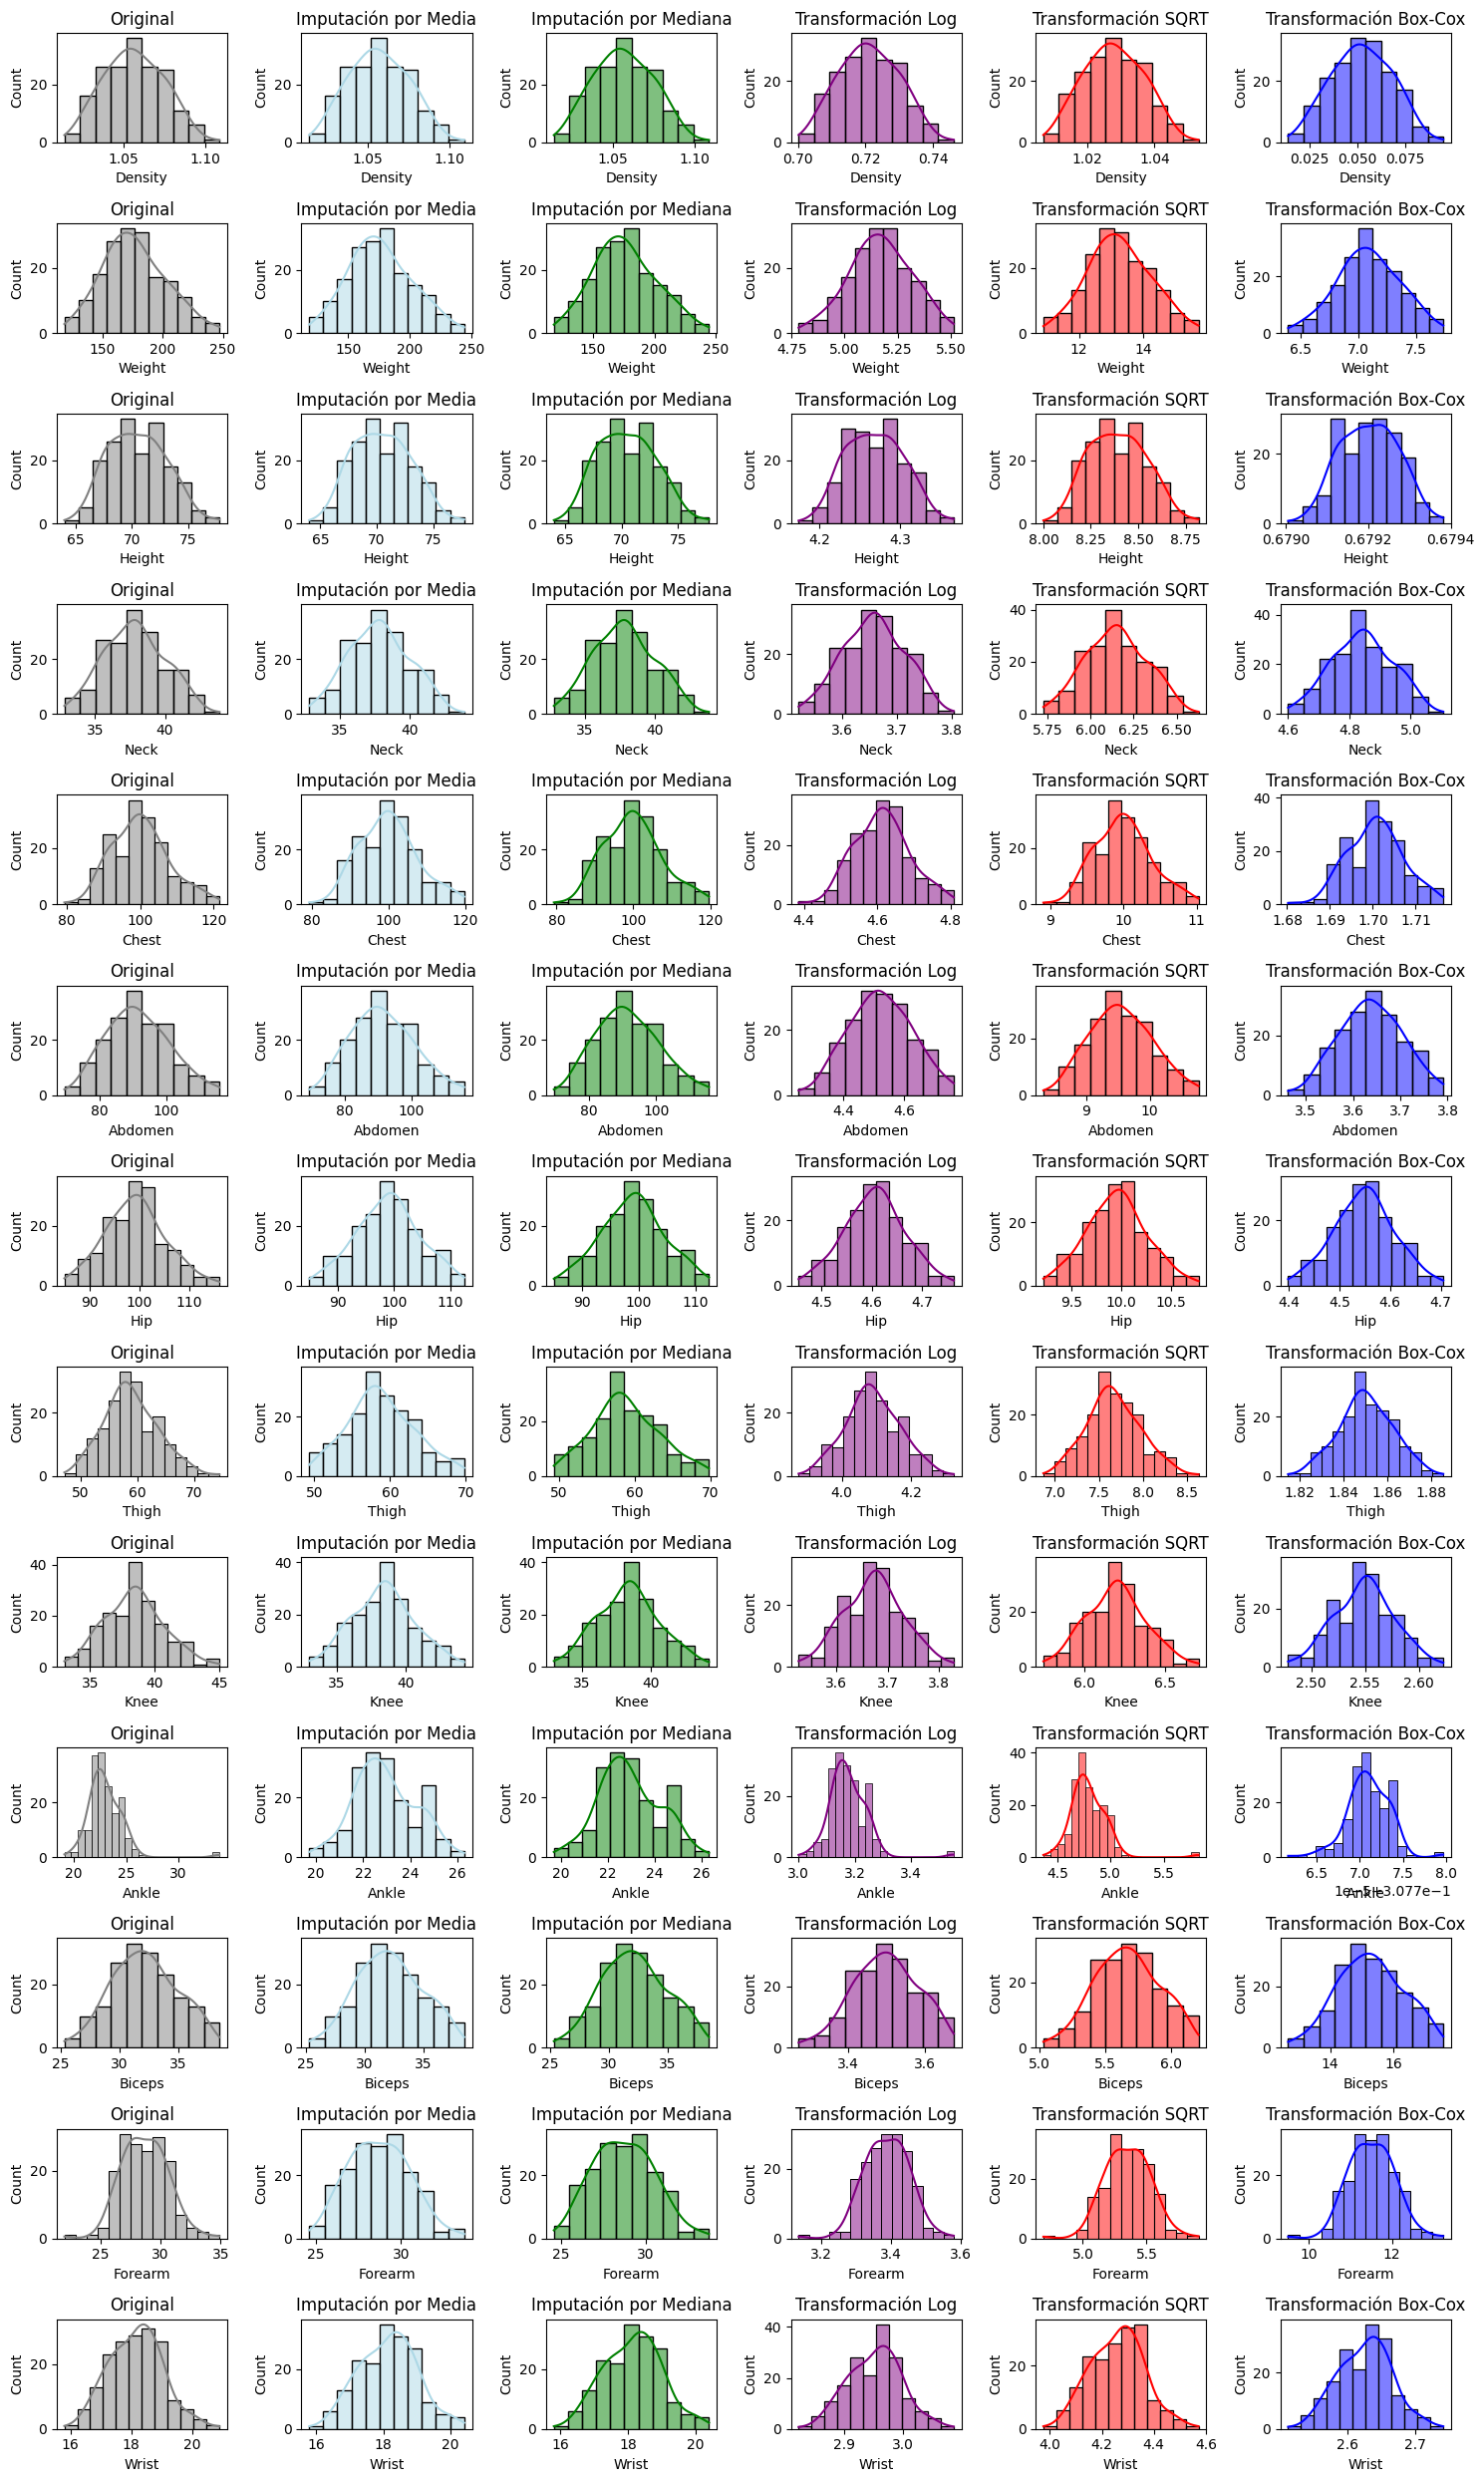

In [266]:
fig, axes = plt.subplots(nrows=13, ncols=6, figsize=(15,25))
colores = ["gray", "lightblue", "green", "purple", "red", "blue"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Transformación Log", "Transformación SQRT", "Transformación Box-Cox"]

for i, col in enumerate(X_train_mean.columns):
    sns.histplot(X_train[col], kde=True, ax=axes[i, 0], color=colores[0])
    sns.histplot(X_train_mean[col], kde=True, ax=axes[i, 1], color=colores[1])
    sns.histplot(X_train_median[col], kde=True, ax=axes[i, 2], color=colores[2])
    sns.histplot(X_train_log[col], kde=True, ax=axes[i, 3], color=colores[3])
    sns.histplot(X_train_sqrt[col], kde=True, ax=axes[i, 4], color=colores[4])
    sns.histplot(X_train_box_cox[col], kde=True, ax=axes[i, 5], color=colores[5])

    for j in range(6):
        axes[i, j].set_xlabel(col)
        axes[i, j].set_title(titulos[j])

plt.tight_layout()
plt.show()

Básandonos en los gráficos anteriores, podemos notar que las transformaciones de [Boxcox](https://www.geeksforgeeks.org/python/box-cox-transformation-using-python/) no solo ayudan en el tratamiento de outliers, sino que también reducen la asimetría de algunas variables (como `Ankle`) y normalizan su distribución (ejemplos: `Hip` y `Weight`).

In [267]:
# Generamos copias del dataset de train, para no modificar al original
y_train_mean = y_train.copy()
y_train_median = y_train.copy()
y_train_log = y_train.copy()
y_train_sqrt = y_train.copy()
y_train_box_cox = y_train.copy()

# Generamos copias del dataset de test, para no modificar al original
y_test_mean = y_test.copy()
y_test_median = y_test.copy()
y_test_log = y_test.copy()
y_test_sqrt = y_test.copy()
y_test_box_cox = y_test.copy()

Q1 = y_train_mean.quantile(0.25)
Q3 = y_train_mean.quantile(0.75)

# Calculamos el IQR para cada columna (exceptuando Age)
IQR = Q3-Q1
# Definimos el mínimo y máximo para determinar Outliers
min_iqr = Q1 - 1.5*IQR
max_iqr = Q3 + 1.5*IQR

# Identificamos los outliers en train y test
outliers_train = (y_train_mean < min_iqr) | (y_train_mean > max_iqr)
outliers_test = (y_test_mean < min_iqr) | (y_test_mean > max_iqr)


In [268]:
media_col = y_train.mean()
mediana_col = y_train.median()

# Imputación por Media
y_train_mean.loc[outliers_train] = media_col
y_test_mean.loc[outliers_test] = media_col

# Imputación por Mediana
y_train_median.loc[outliers_train] = mediana_col
y_test_median.loc[outliers_test] = mediana_col

# Transformación logarítmica
y_train_log = np.log1p(y_train_log)
y_test_log = np.log1p(y_test_log)

# Transformación raíz cuadrada
y_train_sqrt = np.sqrt(y_train_sqrt)
y_test_sqrt = np.sqrt(y_test_sqrt)

# Transformación Box-cox
y_train_box_cox, _ = stats.boxcox(y_train_box_cox)
y_test_box_cox, _ = stats.boxcox(y_test_box_cox)

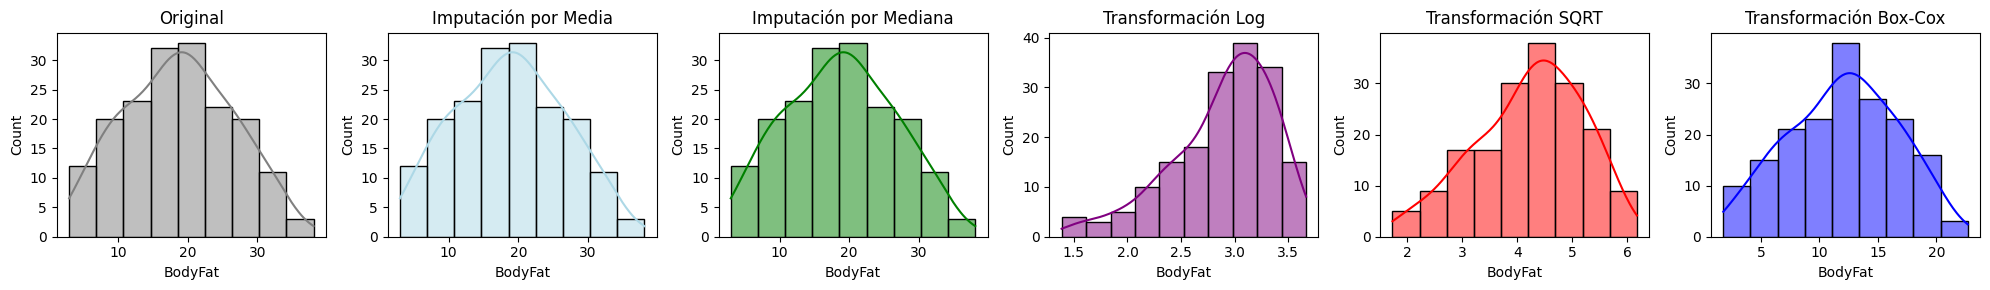

In [269]:
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(20,3))
colores = ["gray", "lightblue", "green", "purple", "red", "blue"]
titulos = ["Original", "Imputación por Media", "Imputación por Mediana", "Transformación Log", "Transformación SQRT", "Transformación Box-Cox"]

sns.histplot(y_train, kde=True, ax=axes[0], color=colores[0])
sns.histplot(y_train_mean, kde=True, ax=axes[1], color=colores[1])
sns.histplot(y_train_median, kde=True, ax=axes[2], color=colores[2])
sns.histplot(y_train_log, kde=True, ax=axes[3], color=colores[3])
sns.histplot(y_train_sqrt, kde=True, ax=axes[4], color=colores[4])
sns.histplot(y_train_box_cox, kde=True, ax=axes[5], color=colores[5])

for j in range(6):
    axes[j].set_xlabel(target)
    axes[j].set_title(titulos[j])

plt.tight_layout()
plt.show()

De manera similar a como sucede en *train*, para la variable `target` (`BodyFat`) la mejor transformación resulta ser la de ***Boxcox***, ya que reduce outliers, ayuda con la asimetría, y normaliza la distribución. En cambio, las transformaciones logarítmicas y por raíz cuadrada tienden a generar una distribución con asimetría a izquierda (más acentuada en el caso de la transformación logarítmica), mediantes que ambas técnicas de imputación tienen una ligera asimetría a derecha.

Para tener un criterio unificado, optamos por tratar los outliers de todas las variables tanto en *train* como en *test* mediante la transformación `Boxcox`.

`NOTA`: Se crea un dataset temporal con las variables `Weight` y `Height`, ya que serán utilizadas en el proceso de creación de nuevas features, y sus valores originales son necesarios

In [270]:
X_train_temp = X_train[["Weight", "Height"]]
X_test_temp = X_test[["Weight", "Height"]]

for col in X_train_box_cox.columns:
    X_train[col] = X_train_box_cox[col]
    X_test[col] = X_test_box_cox[col]

y_train = y_train_box_cox
y_test = y_test_box_cox

In [271]:
# Borramos los datasets extras que se crearon

del X_train_log, X_train_sqrt, X_train_box_cox, X_train_mean, X_train_median, X_test_box_cox, X_test_log, X_test_mean, X_test_median, X_test_sqrt, y_train_box_cox, y_train_log, y_train_sqrt, y_train_mean, y_train_median, y_test_box_cox, y_test_log, y_test_sqrt, y_test_mean, y_test_median

In [272]:
# Mostramos caaracterísticas generales del nuevo X_train
X_train.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000
mean,0.052403,44.562500,7.088997,0.679203,4.843037,1.700612,3.637641,4.548893,1.850257,2.549263,0.307771,15.282957,11.509003,2.626194
std,0.015872,12.588274,0.270455,0.000071,0.099822,0.006467,0.066866,0.059575,0.012498,0.027732,0.000002,1.035458,0.550363,0.039870
min,0.013748,23.000000,6.391299,0.679006,4.600388,1.680234,3.462216,4.399169,1.814630,2.478424,0.307762,12.667472,9.502585,2.512733
25%,0.040163,35.000000,6.913500,0.679148,4.772604,1.695546,3.588411,4.509743,1.842986,2.528926,0.307770,14.525563,11.135245,2.600384
50%,0.052504,43.000000,7.095544,0.679199,4.843792,1.700567,3.636142,4.551083,1.849882,2.550105,0.307771,15.255708,11.490035,2.629016
75%,0.064780,52.250000,7.279583,0.679253,4.915908,1.704639,3.687074,4.582890,1.858232,2.565550,0.307773,15.973263,11.888655,2.655528
max,0.095193,81.000000,7.732162,0.679382,5.106182,1.716431,3.790785,4.704675,1.885483,2.622725,0.307780,17.585919,13.232417,2.741670


In [273]:
# Mostramos caaracterísticas generales del nuevo X_test
X_test.describe()

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,76.000000,76.000000,76.000000,7.600000e+01,76.000000,7.600000e+01,76.000000,7.600000e+01,76.000000,76.000000,7.600000e+01,76.000000,76.000000,76.000000
mean,0.058259,45.631579,1.029607,1.297075e+13,1.363366,3.902873e-01,0.759731,2.463665e-01,0.699730,0.394226,1.949064e-01,2.472932,20773.162926,0.972738
std,0.023924,12.685784,0.001144,3.952836e+12,0.006512,6.245550e-07,0.000325,5.478250e-10,0.000279,0.000006,5.794928e-09,0.051708,5110.569186,0.003322
min,-0.004961,22.000000,1.026774,1.831831e+10,1.344182,3.902858e-01,0.758974,2.463665e-01,0.699097,0.394213,1.949064e-01,2.340966,7289.690858,0.964399
25%,0.042468,38.500000,1.028824,1.028932e+13,1.359573,3.902869e-01,0.759534,2.463665e-01,0.699595,0.394223,1.949064e-01,2.443865,17185.551530,0.970576
50%,0.054995,44.500000,1.029601,1.247511e+13,1.363651,3.902873e-01,0.759717,2.463665e-01,0.699737,0.394227,1.949064e-01,2.468864,21131.979218,0.972947
75%,0.076932,54.000000,1.030355,1.597547e+13,1.367958,3.902877e-01,0.759943,2.463665e-01,0.699890,0.394229,1.949064e-01,2.508833,23846.864644,0.974842
max,0.114543,72.000000,1.033074,2.108531e+13,1.386637,3.902889e-01,0.760633,2.463665e-01,0.700587,0.394243,1.949064e-01,2.627939,35312.997328,0.981376


## Paso 5 - Creación de nuevas features

En este paso se crea la feature de *BMI* o Body Mass Index (Índice de masa corporal).

La misma se obtiene a partir de la columna `Weight` y `Height`, dividiendo la primera por el cuadrado de la segunda.

Como estas columnas están medidadas en libras (*lb*) y pulgadas (*in*), debemos ajustar la formula multiplicandola por $703$. Mas información en la [fuente](https://my.clevelandclinic.org/health/articles/9464-body-mass-index-bmi).

In [274]:
# ===== Paso 5: Agregar feature BMI con Pipeline (lb/in) =====

from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

# 1) Función pura: añade columna BMI = 703 * Weight(lb) / Height(in)^2
def add_bmi(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    # Asegurar tipos numéricos y evitar división por cero/negativos
    h = pd.to_numeric(out["Height"], errors="coerce")
    w = pd.to_numeric(out["Weight"], errors="coerce")
    h = h.where(h > 0, np.nan)  # si Height <= 0 -> NaN (se podrá imputar luego si hace falta)
    out["BMI"] = 703 * w / (h ** 2)
    return out

# 2) Transformer para usar en Pipeline (no “aprende” nada, pero mantiene el patrón)
bmi_adder = FunctionTransformer(add_bmi, validate=False)

# 3) Pipeline SOLO con el paso de BMI
bmi_pipe = Pipeline([("bmi", bmi_adder)])

# 4) Aplicar: fit en TRAIN, transform en TEST (patrón canónico)
X_train_temp = bmi_pipe.fit_transform(X_train_temp)
X_test_temp  = bmi_pipe.transform(X_test_temp)

# Chequeo rápido
print(X_train_temp[["Weight", "Height", "BMI"]].head())

     Weight  Height        BMI
155  171.50   75.25  21.291509
30   182.00   73.75  23.523539
112  178.25   70.00  25.573418
111  183.25   70.00  26.290765
106  200.25   73.50  26.058726


## Paso 6 - Discretización de features

A continuación se discretiza la variable `BMI` en función de los [umbrales definidos por la OMS](https://www.who.int/es/news-room/fact-sheets/detail/obesity-and-overweight), y se crea una nueva variable: `BMI_cat`.

Una vez creada la nueva variable, hay dos opciones posibles: reemplazar `BMI` por `BMI_cat` o mantener ambas.

Consideramos el *mejor enfoque* como aquel que mantiene `BMI` y `BMI_bin/BMI_cat`
- `BMI` continuo aporta la variación fina (27.1 ≠ 27.9) y permite que modelos lineales aprendan una pendiente; también favorece SVM/KNN y cualquier modelo basado en distancias.
- `BMI_cat` (bajo/normal/sobrepeso/obesidad) introduce no linealidad por tramos (umbrales OMS) de forma simple, interpretables en el informe.
- Robustez e interpretabilidad.
    - `BMI_cat` es menos sensible a outliers y facilita conclusiones tipo “en obesidad el riesgo sube X”, mientras BMI mantiene la granularidad numérica.

In [275]:
# ===== Paso 6: Discretización de BMI (sin chequeo) =====
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

def add_bmi_cat(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    
    # Cortes segun OMS
    bins = [-np.inf, 18.5, 25, 30, np.inf]
    labels = ["bajo_peso", "normal", "sobrepeso", "obesidad"]
    out["BMI_cat"] = pd.cut(out["BMI"], bins=bins, labels=labels, right=False)
    return out

bmi_cat_adder = FunctionTransformer(add_bmi_cat, validate=False)

bmi_and_cat_pipe = Pipeline([("bmi", bmi_adder),("bmi_cat", bmi_cat_adder)])

X_train_temp = bmi_and_cat_pipe.fit_transform(X_train_temp)
X_test_temp  = bmi_and_cat_pipe.transform(X_test_temp)

print(X_train_temp[["BMI", "BMI_cat"]].head())

           BMI    BMI_cat
155  21.291509     normal
30   23.523539     normal
112  25.573418  sobrepeso
111  26.290765  sobrepeso
106  26.058726  sobrepeso


En la siguiente celda se hace la transformación de `BoxCox` a la variable `BMI`, para que tenga el mismo tipo de transformación que el resto de las columnas del dataset.

In [276]:
X_train_temp["BMI"], _ = stats.boxcox(X_train_temp["BMI"])
X_test_temp["BMI"], _ = stats.boxcox(X_test_temp["BMI"])

Se agregan las columnas `BMI` y `BMI_cat` a los datasets de *train* y *test* originales.

In [277]:
X_train = X_train.join(X_train_temp[["BMI", "BMI_cat"]])
X_test = X_test.join(X_test_temp[["BMI", "BMI_cat"]])

In [278]:
# Se borran los datasets temporales
del X_train_temp, X_test_temp

## Paso 7 - Codificación de features

En este paso aplicamos la codificación de OneHotEncoding a la variable `BMI_cat`.

Como su cardinalidad es cuatro (`BMI_bajo_peso`, `BMI_normal`, `BMI_sobrepeso` y `BMI_obesidad`), se crearán cuatro variables nuevas, una por cada una de ellas.

Por su parte, la columna original `BMI_cat` será eliminada de los datasets de *train* y *test*, para evitar tener información redundante.

In [279]:
bmi_train = pd.get_dummies(X_train["BMI_cat"], prefix="BMI", dtype=int)

bmi_cols = bmi_train.columns
bmi_test  = pd.get_dummies(X_test["BMI_cat"],  prefix="BMI", dtype=int).reindex(columns=bmi_cols, fill_value=0)

X_train = pd.concat([X_train.drop(columns=["BMI_cat"]), bmi_train], axis=1)
X_test  = pd.concat([X_test.drop(columns=["BMI_cat"]),  bmi_test],  axis=1)

print("Columnas nuevas:", list(bmi_cols))
print(X_train.filter(like="BMI_").head())

Columnas nuevas: ['BMI_bajo_peso', 'BMI_normal', 'BMI_sobrepeso', 'BMI_obesidad']
     BMI_bajo_peso  BMI_normal  BMI_sobrepeso  BMI_obesidad
155              0           1              0             0
30               0           1              0             0
112              0           0              1             0
111              0           0              1             0
106              0           0              1             0


## Paso 8 - Escalado de features

Las columnas como Weight, Height, BMI, Chest, Neck, entre otras, son medidas físicas en distintas unidades (kg, cm, etc.).

Si no son escaladas, variables con rangos más amplios (como peso o abdomen) pueden dominar a otras variables en modelos sensibles a magnitudes. 
- Algunos de estos modelos son *Regresión lineal*, *Ridge/Lasso*, *SVM*, *KNN* y *Redes neuronales*.
- Esto se debe a que estos modelos usan distancias o gradientes, y si las variables no están en la misma escala, el aprendizaje se distorsiona.

Z-score:
- Asegura que todas las variables tengan media 0 y desviación 1, haciendo que ninguna domine solo por su escala.
- Preserva relaciones estadísticas importantes
- Mantiene la distribución relativa y proporcionalidad de los datos.

A diferencia del Min-Max scaling, que puede "aplanar" las diferencias si hay outliers, el z-score tolera mejor valores extremos.

Por estos motivos, se opta por escalar las features mediante `Z-score`. Igualmente, se estudian y comparan ambas metodologías.

Z-score (TRAIN) — media y std esperadas ~0 y ~1:
      BMI_bajo_peso  BMI_normal  BMI_sobrepeso  BMI_obesidad  Density    Age  \
mean         -0.000      -0.000         -0.000         0.000    0.000  0.000   
std           1.003       1.003          1.003         1.003    1.003  1.003   

      Weight  Height   Neck  Chest  Abdomen    Hip  Thigh   Knee  Ankle  \
mean  -0.000   0.000  0.000  0.000   -0.000 -0.000 -0.000 -0.000 -0.000   
std    1.003   1.003  1.003  1.003    1.003  1.003  1.003  1.003  1.003   

      Biceps  Forearm  Wrist    BMI  
mean   0.000   -0.000  0.000  0.000  
std    1.003    1.003  1.003  1.003  

Min-Max (TRAIN) — min y max esperados ~0 y ~1:
               min  max
BMI_bajo_peso  0.0  1.0
BMI_normal     0.0  1.0
BMI_sobrepeso  0.0  1.0
BMI_obesidad   0.0  1.0
Density        0.0  1.0
Age            0.0  1.0
Weight         0.0  1.0
Height         0.0  1.0
Neck           0.0  1.0
Chest          0.0  1.0
Abdomen        0.0  1.0
Hip            0.0  1.0
Thigh     

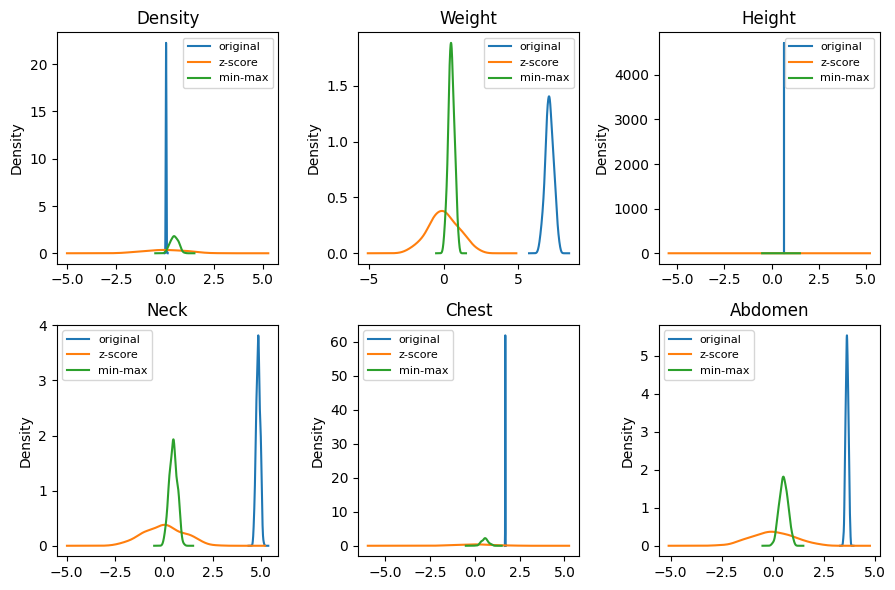

In [283]:
# ===== Paso 8: Escalado (Z-score vs Min-Max) y graficado para analizar


# --- Listas según lo que definiste ---
dummy_cols = ["BMI_bajo_peso", "BMI_normal", "BMI_sobrepeso", "BMI_obesidad"]

num_cols = ["Density","Age","Weight","Height","Neck","Chest","Abdomen","Hip",
    "Thigh","Knee","Ankle","Biceps","Forearm","Wrist", "BMI"]

all_cols = dummy_cols + num_cols
cols_to_process = all_cols

# --- 1) Estandarización (z-score) ---
sc_std = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[cols_to_process] = sc_std.fit_transform(X_train[cols_to_process])  # fit SOLO en TRAIN
X_test_std[cols_to_process]  = sc_std.transform(X_test[cols_to_process])

# --- 2) Normalización (min-max) ---
sc_mm = MinMaxScaler()
X_train_mm = X_train.copy()
X_test_mm  = X_test.copy()
X_train_mm[cols_to_process] = sc_mm.fit_transform(X_train[cols_to_process])    # fit SOLO en TRAIN
X_test_mm[cols_to_process]  = sc_mm.transform(X_test[cols_to_process])

# --- 3) Checks rápidos en TRAIN ---
print("Z-score (TRAIN) — media y std esperadas ~0 y ~1:")
print(X_train_std[cols_to_process].describe().loc[["mean","std"]].round(3))

print("\nMin-Max (TRAIN) — min y max esperados ~0 y ~1:")
print(X_train_mm[cols_to_process].agg(["min","max"]).round(3).T)

# --- 4) Gráficos comparativos  

cols_to_plot = [c for c in ["Density","Weight","Height","Neck","Chest","Abdomen"] if c in cols_to_process][:6]

ncols = 3
nrows = math.ceil(len(cols_to_plot) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 3*nrows))   

for ax, col in zip(axes.flat, cols_to_plot):
    X_train[col].plot(kind="kde", ax=ax, label="original")
    X_train_std[col].plot(kind="kde", ax=ax, label="z-score")
    X_train_mm[col].plot(kind="kde", ax=ax, label="min-max")
    ax.set_title(col)
    ax.legend(fontsize=8)

# Ocultar ejes sobrantes si los hay
for ax in axes.flat[len(cols_to_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [284]:
# ===== Paso 8: Escalado  Z-score   
dummy_cols = ["BMI_bajo_peso", "BMI_normal", "BMI_sobrepeso", "BMI_obesidad"]

num_cols = ["Density","Age","Weight","Height","Neck","Chest","Abdomen","Hip",
    "Thigh","Knee","Ankle","Biceps","Forearm","Wrist", "BMI"] 

all_cols = dummy_cols + num_cols
cols_to_process = all_cols

cols_to_process = [c for c in cols_to_process if c in X_train.columns]

scaler = StandardScaler().fit(X_train[cols_to_process])    
 
X_train.loc[:, cols_to_process] = scaler.transform(X_train[cols_to_process])
X_test.loc[:,  cols_to_process] = scaler.transform(X_test[cols_to_process])

## Paso 9 - Reducción de dimensionalidad

A la hora de estudiar reducir la dimensión del dataset, optamos por realizar un *Análisis de Componentes Principales*.

En particular, buscamos saber cuántas componentes necesitaríamos para explicar aproximadamente el $95\%$ de la varianza total.

En nuestro análisis, encontramos que se puede reducir la dimensión del dataset a *9 componentes*, las cuales explican el $94\%$ de la varianza total del dataset de *train*.

| Componente\Varianza Explicada | Componente $1$ | Componente $2$ | Componente $3$ | Componente $4$ | Componente $5$ | Componente $6$ | Componente $7$ | Componente $8$ | Componente $9$ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Varianza explicada | $52\%$ | $12\%$ | $9\%$ | $8\%$ | $5\%$ | $3\%$ | $2\%$ | $2\%$ | $1\%$

Como esto implicaría reducir la dimensión (en columnas) de un dataset relativamente pequeño a la mitad (19 columnas en *train* y *test*), optamos por NO aplicar reducción de dimensionalidad al dataset de *Body Fat Prediction*.

In [601]:
# ===== Paso 9: PCA (con escalado en train, aplica en test) =====
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Selección de numéricas
# num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

cols_to_process = dummy_cols + num_cols

# 2) Escalado (fit solo en train, transform en test)
scaler_pca = StandardScaler().fit(X_train[cols_to_process])
Xtr_num_sc = scaler_pca.transform(X_train[cols_to_process])
Xte_num_sc = scaler_pca.transform(X_test[cols_to_process])

# 3) PCA: elegir #comp para ≥95% de varianza explicada
pca_full = PCA().fit(Xtr_num_sc)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n95 = int(np.argmax(cumvar >= 0.95) + 1)

pca = PCA(n_components=n95).fit(Xtr_num_sc)
X_train_pca = pd.DataFrame(pca.transform(Xtr_num_sc),
                           index=X_train.index,
                           columns=[f'PCA_{i+1}' for i in range(n95)])
X_test_pca  = pd.DataFrame(pca.transform(Xte_num_sc),
                           index=X_test.index,
                           columns=[f'PCA_{i+1}' for i in range(n95)])

print(f"PCA listo. Componentes para ≥95% varianza: {n95}")
print("X_train_pca shape:", X_train_pca.shape, " | X_test_pca shape:", X_test_pca.shape)


PCA listo. Componentes para ≥95% varianza: 9
X_train_pca shape: (176, 9)  | X_test_pca shape: (76, 9)


In [ ]:
# Obtenemos la varianza de cada una de las variables que explican el 95% total de la varianza del dataset
np.round(pca_full.explained_variance_ratio_,2)[:n95]

array([0.52, 0.12, 0.09, 0.08, 0.05, 0.03, 0.02, 0.02, 0.01])

## Paso 10 - Entrenamiento de Algoritmos

### Paso 10.0 - Funciones básicas

A continuación, se definen una serie de funciones que nos facilitarán la comparación de modelos

In [552]:
import sys, numpy as np, pandas as pd
from packaging.version import parse as V
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer, root_mean_squared_error
from sklearn.model_selection import cross_val_score
import optuna
from optuna.samplers import TPESampler

def _rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))
    
rmse_scorer = make_scorer(_rmse, greater_is_better=False)

# CV
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Dataframe donde se guardarán los mejores modelos y sus métricas
res_df = pd.DataFrame(columns=["modelo","mejor_params","cv_RMSE","test_MAE","test_RMSE","test_R2"])
best_models = {} 

# Sampler para optuna. Esto nos permite que los resultados sean siempre los mismos en cada modelo.
sampler_tpe = TPESampler(seed=random_state)

In [553]:
def eval_and_store(name, search, Xtr, ytr, Xte, yte):
    search.fit(Xtr, ytr)
    best = search.best_estimator_
    y_pred = best.predict(Xte)
    row = {
        "modelo": name,
        "mejor_params": search.best_params_,
        "cv_RMSE": -float(search.best_score_),
        "test_MAE": mean_absolute_error(yte, y_pred),
        "test_RMSE": _rmse(yte, y_pred),
        "test_R2": r2_score(yte, y_pred)
    }
    
    res_df.loc[len(res_df)] = row
    best_models[name] = best
    display(res_df.sort_values("test_RMSE").reset_index(drop=True))
    return best

In [554]:
# Similar a la función eval_and_store, pero recibe un `study` de optuna
def optuna_eval_and_store(model_name, model_class, optuna_study, X_train, y_train, X_test, y_test):
    best_params = optuna_study.best_params
    model_optuna = model_class(**best_params)
    model_optuna.fit(X_train, y_train)
    y_pred = model_optuna.predict(X_test)
    row = {
        "modelo": model_name,
        "mejor_params": best_params,
        "cv_RMSE": optuna_study.best_value,
        "test_MAE": mean_absolute_error(y_test, y_pred),
        "test_RMSE": root_mean_squared_error(y_test, y_pred),
        "test_R2": r2_score(y_test, y_pred)
    }

    res_df.loc[len(res_df)] = row
    best_models[model_name] = model_optuna
    display(res_df.sort_values("test_RMSE").reset_index(drop=True))
    return model_optuna, best_params

In [555]:
# Código provisto por la materia.
# Muestra información en cada iteración de la búsqueda de hiperparámetros bayesiana realizada por Optuna.
# Se utiliza como callback al llamar al método optimize de optuna.
def champion_callback(study, frozen_trial):
    """
    Mostramos menos información, sino es demasiado verboso
    """

    winner = study.user_attrs.get("winner", None)

    if study.best_value and winner != study.best_value:
        study.set_user_attr("winner", study.best_value)
        if winner:
            improvement_percent = (abs(winner - study.best_value) / study.best_value) * 100
            print(
                f"Trial {frozen_trial.number} achieved value: {frozen_trial.value} with "
                f"{improvement_percent: .4f}% improvement"
            )
        else:
            print(f"Initial trial {frozen_trial.number} achieved value: {frozen_trial.value}")

In [556]:
# Esta función nos permite realizar un scatter plot de los valores predecidos vs residuos
def plot_residuals(modelo, X_test, y_test, figsize=(6, 6),
                   xlabel="Valores predichos", ylabel="Residuos", title="Residual Plot"):
    y_pred = modelo.predict(X_test)
    residuals = y_test - y_pred
    plt.figure(figsize=figsize)
    plt.scatter(y_pred, residuals, color='blue', alpha=0.7)
    plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

In [557]:
# Esta función permite graficar los true values contra sus predicciones, para un modelo dado
# Source: https://stackoverflow.com/a/65322979
def plot_true_vs_predicted(modelo, X_test, y_test, figsize=(6,6), title="True values vs Predicciones"):
    y_pred = modelo.predict(X_test)

    plt.figure(figsize=figsize)
    plt.scatter(y_test, y_pred, c='crimson')

    p1 = max(max(y_pred), max(y_test))
    p2 = min(min(y_pred), min(y_test))
    plt.plot([p1, p2], [p1, p2], 'b-')
    plt.xlabel('True Values', fontsize=15)
    plt.ylabel('Predicciones', fontsize=15)
    plt.title(title)
    plt.axis('equal')
    plt.show()

### Paso 10.1 - KNN regressor

`KNN`

 - El mejor KNN fue con 5 vecinos.
 - El RMSE en train (2.31) es más bajo que en test (4.70) se entiende que hay algo de overfitting.
 - El R² en test es negativo (-0.09) . Significa que el modelo no logra explicar la varianza mejor que un modelo tonto que predice siempre la media.

**KNN** no rindió bien para este dataset . Probablemente porque las variables están muy correlacionadas y KNN sufre en alta dimensión.

***Descripción***

En este caso trabajamos con el modelo [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) de Scikit learn, que nos permite aplicar *KNN* para regresión.

Se optimizaron los siguientes hiperparámetros, mediante [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html):

- `n_neighbors`: con valores [$3$, $5$, $7$, $9$, $11$, $15$, $21$, $31$]
- `weights`: con valores $uniform$ y $distance$.
- `p`: con valores $1$ y $2$.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron mediante el framework *optuna*.

- `n_neighbors`: $5$.
- `weights`: $distance$.
- `p`: $2$.

El modelo `KNN` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $2.471977$
- *MAE* en test: $3.747122$
- *RMSE* en test: $4.706763$
- *R2* en test: $-0.093858$

***Conclusiones para KNN***

- El modelo tuvo malos resultados al ajustar tanto en *train* (*RMSE* de $2.471977$ para cross validation) como en *test* (*RMSE* de $4.706763$).
- El modelo obtuvo un métrica de R2 negativa en test ($-0.093858$), lo cual indica que las predicciones que realiza son peores que "predecir al azar" ([más info aquí](https://help.desmos.com/hc/en-us/articles/202529139-Why-am-I-seeing-a-negative-R-2-value#:~:text=In%20practice%2C%20R2%20will,the%20mean%20of%20the%20data.)).
    - Esto también puede verse en el residual plot de este modelo.
- Además, se realizaron los gráficos de *Valores predichos vs reales* y de *residuos*, en donde puede observarse el mal rendimiento del modelo para el dataset de *body_fat*.
- Estos malos resultados pueden deberse a que haya variables correlacionadas, además de que *KNN* sufre por alta dimensionalidad (*19 columnas* para este dataset).
- En conclusión, `KNN` ***no*** es el modelo más ***apto*** para trabajar con estos datos.

In [558]:
from sklearn.neighbors import KNeighborsRegressor

knn = GridSearchCV(
    KNeighborsRegressor(),
    {"n_neighbors":[3,5,7,9,11,15,21,31], "weights":["uniform","distance"], "p":[1,2]},
    # scoring=rmse_scorer,
    # "neg_root_mean_squared_error"
    scoring=rmse_scorer,
    cv=cv, n_jobs=-1, verbose=0
)
best_knn = eval_and_store("KNN", knn, X_train, y_train, X_test, y_test)

,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


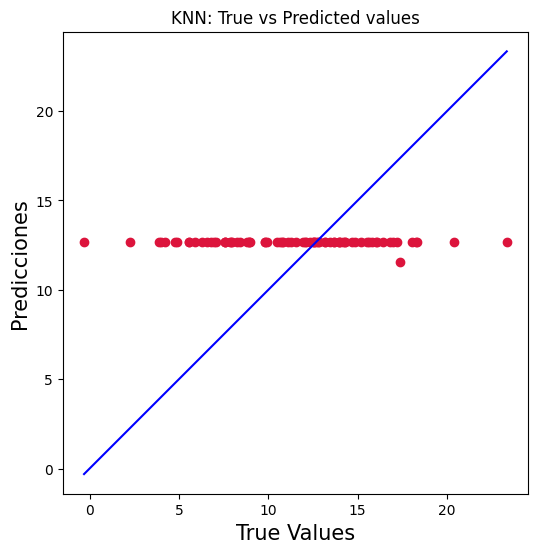

In [559]:
plot_true_vs_predicted(best_knn, X_test, y_test, title="KNN: True vs Predicted values")

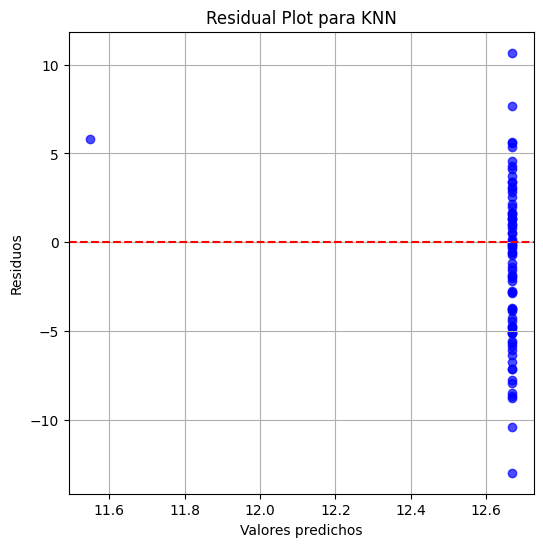

In [560]:
plot_residuals(best_knn, X_test, y_test, title="Residual Plot para KNN")

### Paso 10.2 - SVM regressor

***Descripción***

En este caso trabajamos con el modelo [SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) de Scikit learn, que nos permite aplicar *SVM* para regresión.

A la hora de optimizar, nos basamos en los siguientes hiperparámetros:

- `kernel`
    - Indica el tipo de kernel a utilizar.
    - Valores que acepta: "linear", "poly", "rbf", "sigmoid", "precomputed"
    - Valor que utilizaremos: "linear", "poly", "rbf", "sigmoid"
- `degree`
    - Solo aplica para el kernel `poly`.
    - Representa el grado del polinomio que se utilizará como kernel.
    - Utilizaremos valores entre 2 y 5, ya que valores más grandes podrían causar `overfitting`.
- `gamma`
    - Acepta los strings *scale* y *auto*, como así también un *float* NO negativo.
    - Utilizaremos valores en el rango $0.0001$ y $1$, con escala logaritmica.
- `C`
    - Parámetro de regularización.
    - Utilizaremos valores entre $1$ y $1000$, con escala logaritmica.
- `epsilon`
    - Debe ser un *float* NO negativo.
    - Utilizaremos valores en el rango $0.0001$ y $1$, con escala logaritmica.

La búsqueda de hiperparámetros se realizará mediante el framework [optuna](https://optuna.readthedocs.io/en/stable/index.html), en particular, con 100 iteraciones/trials.

En cada una de estas iteraciones, se utilizará la cross validation con $5$ splits mediante [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), y se buscará minimizar el error cuadrático medio, utilizando la métrica [neg_root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) de Scikit learn.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron mediante el framework *optuna*.
- *kernel*: `rbf`
- *gamma*: `0.00999197949182039`
- *epsilon*: `0.00652658039894747`
- *C*: `7.77566918266932`

El modelo `SVR` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $0.731850$
- *MAE* en test: $3.689215$
- *RMSE* en test: $4.584282$
- *R2* en test: $-0.037669$

***Conclusiones para SVR***

- El modelo ajustó bien en el dataset de *train* (*RMSE* cercano a $0.7$ para cross validation), pero no sucedió lo mismo en *test* (*RMSE* cercano a $4.5$), en donde el *RMSE* es *6 veces* superior al de *train*.
- El modelo obtuvo un métrica de R2 negativa en test ($-0.037669$), lo cual indica que las predicciones que realiza son peores que "predecir al azar" ([más info aquí](https://help.desmos.com/hc/en-us/articles/202529139-Why-am-I-seeing-a-negative-R-2-value#:~:text=In%20practice%2C%20R2%20will,the%20mean%20of%20the%20data.)).
    - Esto también puede verse en el residual plot de este modelo.
- Además, se realizaron los gráficos de *Valores predichos vs reales* y de *residuos*, en donde puede observarse el mal rendimiento del modelo para el dataset de *bodyfat*.
- En conclusión, `SVR` ***no*** es el modelo más ***apto*** para trabajar con estos datos.

In [561]:
from sklearn.svm import SVR

# Función objetivo para SVR, necesaria para trabajar con optuna.
def objective_SVR(trial):
    kernel = trial.suggest_categorical("kernel", ["linear", "poly", "rbf", "sigmoid"])
    gamma = trial.suggest_float("gamma", 1e-4, 1.0, log=True)
    epsilon = trial.suggest_float("epsilon", 1e-4, 1.0, log=True)
    C_ = trial.suggest_float("C", 1, 1000, log=True)
    
    match kernel:
        case "poly":
            degree = trial.suggest_int("degree", 2, 5)
            svr_model = SVR(kernel=kernel, degree=degree, gamma=gamma, epsilon=epsilon, C=C_)
        case "sigmoid" | "rbf":
            svr_model = SVR(kernel=kernel, gamma=gamma, epsilon=epsilon, C=C_)
        case _: # "linear"
            svr_model = SVR(kernel=kernel)
    
    score = cross_val_score(svr_model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    # Como utilizamos `neg_root_mean_squared_error`, multiplicamos por -1
    # More info: https://datascience.stackexchange.com/a/93534
    return score.mean() * (-1)

In [562]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

svr_study = optuna.create_study(direction="minimize")
svr_study.optimize(objective_SVR, n_trials=100, callbacks=[champion_callback])
best_svr, best_svr_params = optuna_eval_and_store("SVR-optuna", SVR, svr_study, X_train, y_train, X_test, y_test)

Initial trial 0 achieved value: 1.0824795811021724
Trial 18 achieved value: 0.7593070911955213 with  42.5615% improvement
Trial 25 achieved value: 0.7539780469963093 with  0.7068% improvement
Trial 27 achieved value: 0.7352519977398995 with  2.5469% improvement
Trial 53 achieved value: 0.7330013822083166 with  0.3070% improvement
Trial 65 achieved value: 0.7329095507161092 with  0.0125% improvement
Trial 71 achieved value: 0.7318905594518086 with  0.1392% improvement
Trial 98 achieved value: 0.7318501599074918 with  0.0055% improvement


,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
1,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


***True vs Predicted values***

En el siguiente gráfico se puede observar el valor predicho por el modelo *XGBoost* para cada observación de *X_test*.

Estos valores son comparados con las medidas reales (*y_test*).

Se grafica en azul la función identidad ($y=x$), que representaría el caso en donde el valor predicho coincide con el valor real.

Los puntos rojos ubicados fuera de dicha recta representan medicione erróneas.

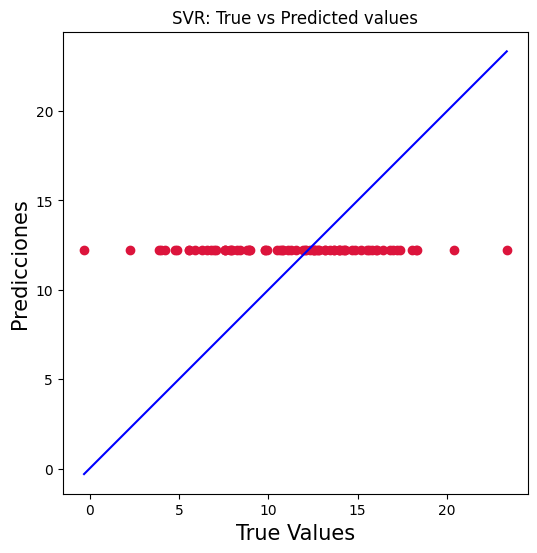

In [563]:
plot_true_vs_predicted(best_svr, X_test, y_test, title="SVR: True vs Predicted values")

***Residual Plot***

En el siguiente gráfico se pueden observar los residuos que se obtuvieron para el modelo *XGBoost*.

$Residuo = predicción - valor\_real$

A mayor residuo, más alejados estarán los puntos azules del cero (línea recta con color rojo), lo cual indica una mala predicción en *test*.

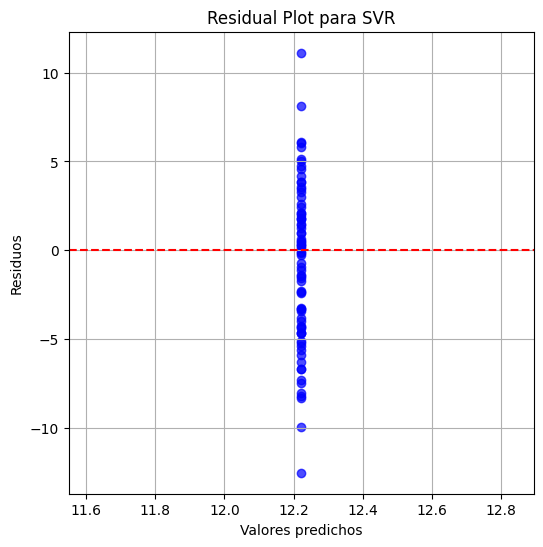

In [564]:
plot_residuals(best_svr, X_test, y_test, title="Residual Plot para SVR")

### Paso 10.3 - Decision Tree

***Descripción***

En este caso trabajamos con el modelo [Decision Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) de Scikit learn, que nos permite aplicar *árboles de regresión*.

A la hora de optimizar, nos basamos en los siguientes hiperparámetros:

- `max_depth`
    - Máxima profundidad del árbol.
    - Utilizaremos estos valores: $None$, $5$, $10$, $20$, $30$.
- `min_samples_split`
    - Cantidad mínima de ejemplos/registros necesarios para hacer un split.
    - Estudiaremos los valores $2$, $5$, $10$, $20$.
- `min_samples_leaf`
    - Cantidad mínima de ejemplos/registros necesarios para ser considerado un nodo hoja.
    - Estudiaremos los valores $1$, $2$, $4$, $8$.
- `ccp_alpha`
    - A mayor valor, se aplica un *prunning* más agresivo. Esto genera árboles más pequeños, que puede ayudar a *prevenir overfitting*.
    - Estudiaremos los valores $0.1$, $0.01$, $0.001$, $0.0$.

La búsqueda de hiperparámetros se realizará mediante el framework [optuna](https://optuna.readthedocs.io/en/stable/index.html), en particular, con 100 iteraciones/trials.

En cada una de estas iteraciones, se utilizará la cross validation con $5$ splits mediante [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), y se buscará minimizar el error cuadrático medio, utilizando la métrica [neg_root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) de Scikit learn.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron:
- *max_depth*: `None`
- *min_samples_split*: `5`
- *min_samples_leaf*: `2`
- *ccp_alpha*: `0`

El modelo `Decision Tree` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $1.173618$
- *MAE* en test: $2.696183$
- *RMSE* en test: $3.658622$
- *R2* en test: $0.339077$

***Conclusiones para Decision Tree***

- El modelo ajustó bien en el dataset de *train* (*RMSE* de $1.173618$ para cross validation), pero tuvo un valor mucho más alto en *test* (*RMSE* de $3.658622$), es decir, presenta *overfitting* en test.
- En cuanto a la métrica de *R2*, el modelo obtuvo en *test* $0.339077$, lo cual indica que ***NO*** está capturando bien los datos en *test*.
- Esto se debe a los valores que toma en *max_depth* ($None$, o sin límite de profundidad) y **ccp_alpha** ($0$, o no realiza prunning/podado del árbol), lo cual genera *overfitting* en el modelo.


In [566]:
from sklearn.tree import DecisionTreeRegressor

# Función objetivo para Decision Tree, necesaria para trabajar con optuna.
def objective_DecisionTree(trial):
    max_depth = trial.suggest_categorical("max_depth", [None,10,20,30])
    min_samples_split = trial.suggest_categorical("min_samples_split", [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 4])
    ccp_alpha = trial.suggest_categorical("ccp_alpha", [0.1, 0.01, 0.001, 0.0])

    dt_model = DecisionTreeRegressor(random_state=random_state,
                                     max_depth=max_depth,
                                     min_samples_split=min_samples_split,
                                     min_samples_leaf=min_samples_leaf,
                                     ccp_alpha=ccp_alpha
                                     )
    
    score = cross_val_score(dt_model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    # Como utilizamos `neg_root_mean_squared_error`, multiplicamos por -1
    # More info: https://datascience.stackexchange.com/a/93534
    return score.mean() * (-1)

In [567]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

dt_study = optuna.create_study(direction="minimize")
dt_study.optimize(objective_DecisionTree, n_trials=100, callbacks=[champion_callback])
best_dt, best_dt_params = optuna_eval_and_store("Decision-Tree-optuna", DecisionTreeRegressor, dt_study, X_train, y_train, X_test, y_test)

Initial trial 0 achieved value: 1.5310321174967403
Trial 1 achieved value: 1.3708826235249885 with  11.6822% improvement
Trial 3 achieved value: 1.2391474933795652 with  10.6311% improvement
Trial 19 achieved value: 1.1736176861297836 with  5.5836% improvement


,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,Decision-Tree-optuna,"{'max_depth': None, 'min_samples_split': 5, 'm...",1.173618,2.696183,3.658622,0.339077
1,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
2,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


***True vs Predicted values***

En el siguiente gráfico se puede observar el valor predicho por el modelo *Decision Tree* para cada observación de *X_test*.

Estos valores son comparados con las medidas reales (*y_test*).

Se grafica en azul la función identidad ($y=x$), que representaría el caso en donde el valor predicho coincide con el valor real.

Los puntos rojos ubicados fuera de dicha recta representan medicione erróneas.

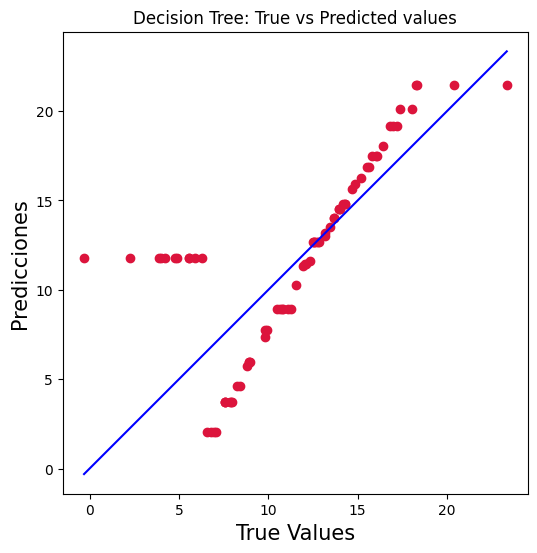

In [609]:
plot_true_vs_predicted(best_dt, X_test, y_test, title="Decision Tree: True vs Predicted values")

***Residual Plot***

En el siguiente gráfico se pueden observar los residuos que se obtuvieron para el modelo *Decision Tree*.

$Residuo = predicción - valor\_real$

A mayor residuo, más alejados estarán los puntos azules del cero (línea recta con color rojo), lo cual indica una mala predicción en *test*.

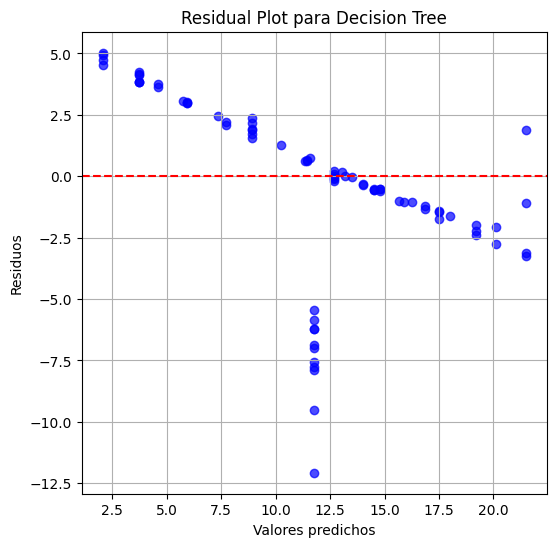

In [610]:
plot_residuals(best_dt, X_test, y_test, title="Residual Plot para Decision Tree")

### Paso 10.4 - Random Forest

***Descripción***

En este caso trabajamos con el modelo [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) de Scikit learn, que nos permite aplicar *Random Forest (RF)* para regresión.

A la hora de optimizar, nos basamos en los siguientes hiperparámetros:

- `n_estimators`
    - Cantidad de árboles estimadores que se utilizarán.
    - Utilizaremos los siguientes valores: $100$, $500$, $1000$, $1500$.
- `criterion`
    - Función que mide la calidad de un split.
    - Los valores posibles son $squared\_error$, $absolute\_error$, $friedman\_mse$, $poisson$.
    - Estudiaremos todos los valores posibles.
- `max_depth`
    - Máxima profundidad del árbol.
    - Utilizaremos estos valores: $None$, $10$, $20$, $30$.
- `min_samples_split`
    - Cantidad mínima de ejemplos/registros necesarios para hacer un split.
    - Estudiaremos los valores $2$, $5$, $10$.
- `min_samples_leaf`
    - Cantidad mínima de ejemplos/registros necesarios para ser considerado un nodo hoja.
    - Estudiaremos los valores $1$, $2$, $4$.
- `max_features`
    - El número de features para considerar al hacer splits.
    - Utilizaremos los valores: $sqrt$, $log2$, $None$.
- `bootstrap`
    - Indica si se hace bootstraping al trabajar con cada árbol. Si es falso, se utiliza todo el dataset en cada árbol.
    - Booleano, default a $true$.
    - Utilizaremos el valor por defecto.
- `ccp_alpha`
    - A mayor valor, se aplica un *prunning* más agresivo. Esto genera árboles más pequeños, que puede ayudar a *prevenir overfitting*.
    - Estudiaremos los valores $0.1$, $0.01$, $0.001$, $0.0$.

La búsqueda de hiperparámetros se realizará mediante el framework [optuna](https://optuna.readthedocs.io/en/stable/index.html), en particular, con 100 iteraciones/trials.

En cada una de estas iteraciones, se utilizará la cross validation con $5$ splits mediante [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), y se buscará minimizar el error cuadrático medio, utilizando la métrica [neg_root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) de Scikit learn.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron mediante el framework *optuna*.
- *n_estimators*: `500`
- *criterion*: `absolute_error`
- *max_depth*: `30`
- *min_samples_split*: `5`
- *min_samples_leaf*: `2`
- *max_features*: `None`
- *ccp_alpha*: `0.01`

El modelo `Random Forest` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $0.936206$
- *MAE* en test: $1.729450$
- *RMSE* en test: $2.119003$
- *R2* en test: $0.778293$

***Conclusiones para Random Forest***

- El modelo ajustó bien en el dataset de *train* (*RMSE* cercana a $0.9$ para cross validation), pero no sucedió lo mismo en *test* (*RMSE* cercana a $2.1$), es decir, presenta *overfitting* en test.
- En cuanto a la métrica de *R2*, el modelo obtuvo en *test* un valor cercano $0.77$, lo cual indica que está capturando bien los datos en *test*.
- Se realizaron los gráficos de *valores reales vs predichos* y de *residuos*, y en ambos se puede observar que hay casos cuyas predicciones difieren bastante de sus valores reales.
- A partir de estas métricas y gráficos, podemos decir que el modelo de *Random Forest* tiene *overfitting* en test.
- Igualmente, *Random Forest* tiene mejor performance que modelos como *KNN* y *SVM*, aunque si es menor que la performance de *Decision Tree*.
    - Esto puede deberse a que en nuestro caso, el modelo trabaja con $500$ estimadores/árboles (hiperparámetro *n_estimators*) de profundidad máxima igual a $30$ (*max_depth*).
    - Un árbol de profundidad $30$ puede generar *overfitting*, pero al ser un modelo de ensamble, la varianza total queda definida por el promedio de las varianzas de los $500$ árboles utilizados.
    - Es decir, si bien puede haber casos donde un árbol tiene mucha varianza, esta puede reducirse al promediar con las varianzas de los otros árboles.

Como conclusión, podemos decir que para el dataset de *body_fat* el modelo de *Random Forest* es uno de los cantidatos a considerar como mejor modelo.

In [570]:
from sklearn.ensemble import RandomForestRegressor

# Función objetivo para Random Forest, necesaria para trabajar con optuna.
def objective_RF(trial):
    # A pesar que hay varios hiperparámetros numéricos (int/float), utilizamos suggest_categorical.
    # Esto nos permite especificar que valores puntuales queremos probar.
    n_estimators = trial.suggest_categorical("n_estimators", [100, 500, 1000, 1500])
    criterion = trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "friedman_mse", "poisson"])
    max_depth = trial.suggest_categorical("max_depth", [None,10,20,30])
    min_samples_split = trial.suggest_categorical("min_samples_split", [2, 5, 10])
    min_samples_leaf = trial.suggest_categorical("min_samples_leaf", [1, 2, 4])
    max_features = trial.suggest_categorical("max_features", ["sqrt","log2", None])
    ccp_alpha = trial.suggest_categorical("ccp_alpha", [0.1, 0.01, 0.001, 0.0])

    rf_model = RandomForestRegressor(random_state=random_state, n_jobs=-1,
                          n_estimators=n_estimators,
                          criterion=criterion,
                          max_depth=max_depth,
                          min_samples_split=min_samples_split,
                          min_samples_leaf=min_samples_leaf,
                          max_features=max_features,
                          ccp_alpha=ccp_alpha
                          )
    
    score = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    # Como utilizamos `neg_root_mean_squared_error`, multiplicamos por -1
    # More info: https://datascience.stackexchange.com/a/93534
    return score.mean() * (-1)

***IMPORTANTE***: la siguiente celda suele demorar cerca de 25 minutos en ejecutarse.

In [571]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

rf_study = optuna.create_study(direction="minimize")
rf_study.optimize(objective_RF, n_trials=100, callbacks=[champion_callback])
best_rf, best_rf_params = optuna_eval_and_store("RF-optuna", RandomForestRegressor, rf_study, X_train, y_train, X_test, y_test)

Initial trial 0 achieved value: 1.9131099479692335
Trial 1 achieved value: 1.0313592772363438 with  85.4940% improvement
Trial 2 achieved value: 0.9375897616007963 with  10.0011% improvement
Trial 14 achieved value: 0.9368074690570423 with  0.0835% improvement
Trial 56 achieved value: 0.9362402192117179 with  0.0606% improvement
Trial 85 achieved value: 0.936205898441423 with  0.0037% improvement


,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,RF-optuna,"{'n_estimators': 500, 'criterion': 'absolute_e...",0.936206,1.729450,2.119003,0.778293
1,Decision-Tree-optuna,"{'max_depth': None, 'min_samples_split': 5, 'm...",1.173618,2.696183,3.658622,0.339077
2,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
3,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


***True vs Predicted values***

En el siguiente gráfico se puede observar el valor predicho por el modelo *Random Forest* para cada observación de *X_test*.

Estos valores son comparados con las medidas reales (*y_test*).

Se grafica en azul la función identidad ($y=x$), que representaría el caso en donde el valor predicho coincide con el valor real.

Los puntos rojos ubicados fuera de dicha recta representan medicione erróneas.

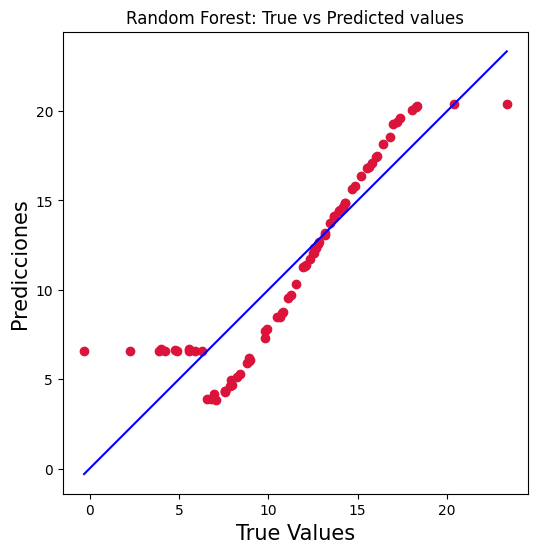

In [572]:
plot_true_vs_predicted(best_rf, X_test, y_test, title="Random Forest: True vs Predicted values")

***Residual Plot***

En el siguiente gráfico se pueden observar los residuos que se obtuvieron para el modelo *Random Forest*.

$Residuo = predicción - valor\_real$

A mayor residuo, más alejados estarán los puntos azules del cero (línea recta con color rojo), lo cual indica una mala predicción en *test*.

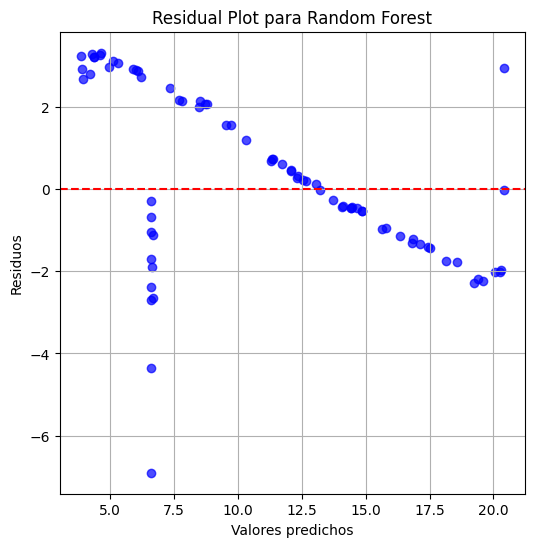

In [573]:
plot_residuals(best_rf, X_test, y_test, title="Residual Plot para Random Forest")

### Paso 10.5 - HistGradientBoostingRegressor

***Descripción***

En este caso trabajamos con el modelo [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html) de Scikit learn, que nos permite aplicar *Histogram Gradient Boosting* para regresión.

A la hora de optimizar, nos basamos en los siguientes hiperparámetros:

- `loss`
    - Función de perdida utilizada en el proceso de *boosting*.
    - Posibles valores: `squared_error, absolute_error, gamma, poisson, quantile`
    - Optamos por explorar todos los valores posibles.
- `quantile`
    - Especifica que cuantil estimar.
    - Solo aplica cuando `loss` es `quantile`.
    - Utilizaremos los siguientes valores: $0.001$, $0.01$, $0.1$, $0.5$, $0.9$.
- `learning_rate`
    - Se utiliza como factor de *shrinkage* en cada iteración de *boosting*.
    - En caso de utilizar valores más pequeños, es posible que haya que aumentar el valor de `max_iter`.
    - Utilizaremos los valores $0.01$, $0.05$, $0.1$.
- `max_iter`
    - El número máximo de iteraciones en el proceso de boosting (o máximo número de árboles).
    - Suele utilizarse junto a *early stopping* junto a valores grandes (ej: *1000*).
    - Utilizaremos valores entre $100$ y $1000$, con saltos de a $100$.
- `max_leaf_nodes`
    - Máximo número de hojas por árbol.
    - Estrictamente debe ser mayor a 1.
    - Default: 31.
    - Utilizaremos valores entre $2$ y $32$, con saltos de a $5$.
- `max_depth`
    - Máxima profundidad de un árbol.
    - Utilizaremos valores entre $3$ y $10$, con saltos de a $1$.
- `min_samples_leaf`
    - Cantidad mínima de registros por hoja.
    - Default: 20.
    - Se utilizarán valores entre $1$ y $15$, con saltos de a $2$. Esto se debe a que el dataset es relativamente pequeño, y para estos casos se recomienda utilizar valores menores al default.
- `l2_regularization`
    - Regularización $L2$.
    - El valor $0$ significa que no se aplicará regularización $L2$.
    - Se utilizarán valores entre $0.0001$ y $0.01$, con escala logaritmica.
- `early_stopping`
    - Posibles valores: `auto`, o booleano.
    - Si se utiliza `auto`, early stopping se habilita cuando hay más de 10000 registros.
    - Valor por defecto: `auto`.
    - Optamos por utilizar el valor por defecto.

La búsqueda de hiperparámetros se realizará mediante el framework [optuna](https://optuna.readthedocs.io/en/stable/index.html), en particular, con 100 iteraciones/trials.

En cada una de estas iteraciones, se utilizará la cross validation con $5$ splits mediante [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), y se buscará minimizar el error cuadrático medio, utilizando la métrica [neg_root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) de Scikit learn.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron mediante el framework *optuna*.
- *loss*: `absolute_error`
- *learning_rate*: `0.05`
- *max_iter*: `800`
- *max_leaf_nodes*: `12`
- *max_depth*: `3`
- *min_samples_leaf*: `1`
- *l2_regularization*: `0.003424308778969859`

El modelo `HistGradientBoostingRegressor` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $0.730105$
- *MAE* en test: $2.474978$
- *RMSE* en test: $3.507054$
- *R2* en test: $0.392703$

***Conclusiones para Histogram-Based Gradient Boosting (HGB)***

- El modelo ajustó bien en el dataset de *train* (*RMSE* cercano a $0.7$ para cross validation), pero no sucedió lo mismo en *test* (*RMSE* de $3.507054$).
- En cuanto a la métrica de *R2*, el modelo obtuvo en *test* $0.392703$, es decir, capta aproximadamente el $39\%$ de la variabilidad de los datos.
- Se realizan también gráficos de *valores reales vs predichos* como de *residuos*, en donde se observa que hay gran cantidad de casos en donde la predicción se diferencia bastante del valor real.
- En función de todo lo mencionado anteriormente, podemos afirmar que *HGB* genera *overfitting* sobre el dataset de *test*.

Si bien el modelo *HGB* tiene mejor rendimiento para el dataset de estudio que los modelos *KNN* y *SVR*, ***NO*** mejora la performance de *Random Forest*.

Esto puede deberse al tamaño del dataset, el cual es de *252 registros* (*train* con $176$, y *test* con $76$) y *19 columnas*.

- Un dataset de *train* pequeño puede ser la causa de que la optimización del hiperparámetro *max_depth* de como resultado $3$.
  - Esto implica que los estimadores/árboles del modelo sean pequeños, es decir, generen más sesgo (*underfitting*) que varianza (*overfitting*).
  - Como este es un modelo de *boosting*, cada estimador trabaja sobre la salida del estimador anterior (arquitectura secuencial), mejorando los errores de estos últimos.
  - Lo que podría suceder en nuestro caso es que la cantidad de estimadores (ni la cantidad de iteraciones, que es *max_iter* $800$) no sea la indicada para mejorar estos errores.

En conclusión, podemos decir que *HGB* NO es el modelo ideal para este dataset, principalmente por la poca cantidad de registros que presenta. 

In [585]:
res_df

,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858
1,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
2,Decision-Tree-optuna,"{'max_depth': None, 'min_samples_split': 5, 'm...",1.173618,2.696183,3.658622,0.339077
3,RF-optuna,"{'n_estimators': 500, 'criterion': 'absolute_e...",0.936206,1.729450,2.119003,0.778293
4,HGB-optuna,"{'loss': 'absolute_error', 'learning_rate': 0....",0.730105,2.474978,3.507054,0.392703
5,XGB-optuna,"{'max_depth': 10, 'min_child_weight': 1, 'subs...",0.860901,2.221381,3.111064,0.522103


In [574]:
from sklearn.ensemble import HistGradientBoostingRegressor

# Función objetivo para HGB, necesaria para trabajar con optuna.
def objective_HGB(trial):
    loss = trial.suggest_categorical("loss", ["squared_error", "absolute_error", "gamma", "poisson", "quantile"])
    learning_rate = trial.suggest_categorical("learning_rate", [0.01, 0.05, 0.1])
    max_iter = trial.suggest_int("max_iter", 100, 1000, step=100) # Entre 100 y 1000, con saltos de a 100.
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 32, step=5) # Entre 2 y 32, con saltos de a 5.
    max_depth = trial.suggest_int("max_depth", 3, 10, step=1)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 15, step=2)
    l2_regularization = trial.suggest_float("l2_regularization", 1e-4, 1e-2, log=True)
    
    match loss:
        case "quantile":
            quantile = trial.suggest_categorical("quantile", [0.001, 0.01, 0.1, 0.5, 0.9])
        case _:
            quantile = None
    
    hgb_model = HistGradientBoostingRegressor(random_state=random_state,
                                              loss=loss,
                                              learning_rate=learning_rate,
                                              max_iter=max_iter,
                                              max_leaf_nodes=max_leaf_nodes,
                                              max_depth=max_depth,
                                              min_samples_leaf=min_samples_leaf,
                                              l2_regularization=l2_regularization,
                                              quantile=quantile
                                            )
    
    score = cross_val_score(hgb_model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    # Como utilizamos `neg_root_mean_squared_error`, multiplicamos por -1
    # More info: https://datascience.stackexchange.com/a/93534
    return score.mean() * (-1)

***IMPORTANTE***: la siguiente celda suele demorar cerca de 12 minutos en ejecutarse.

In [575]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

hgb_study = optuna.create_study(direction="minimize")
hgb_study.optimize(objective_HGB, n_trials=100, callbacks=[champion_callback])
best_hgb, best_hgb_params = optuna_eval_and_store("HGB-optuna", HistGradientBoostingRegressor, hgb_study, X_train, y_train, X_test, y_test)

Initial trial 0 achieved value: 9.116446905196714
Trial 1 achieved value: 1.2011027162014987 with  659.0064% improvement
Trial 2 achieved value: 0.9299097952912623 with  29.1634% improvement
Trial 20 achieved value: 0.8516932247565017 with  9.1837% improvement
Trial 21 achieved value: 0.8341598777459204 with  2.1019% improvement
Trial 42 achieved value: 0.8012241183312249 with  4.1107% improvement
Trial 52 achieved value: 0.75393724030742 with  6.2720% improvement
Trial 82 achieved value: 0.7458136493215151 with  1.0892% improvement
Trial 84 achieved value: 0.7307913723394728 with  2.0556% improvement
Trial 91 achieved value: 0.7301051802308824 with  0.0940% improvement


,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,RF-optuna,"{'n_estimators': 500, 'criterion': 'absolute_e...",0.936206,1.729450,2.119003,0.778293
1,HGB-optuna,"{'loss': 'absolute_error', 'learning_rate': 0....",0.730105,2.474978,3.507054,0.392703
2,Decision-Tree-optuna,"{'max_depth': None, 'min_samples_split': 5, 'm...",1.173618,2.696183,3.658622,0.339077
3,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
4,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


***True vs Predicted values***

En el siguiente gráfico se puede observar el valor predicho por el modelo *HGB* para cada observación de *X_test*.

Estos valores son comparados con las medidas reales (*y_test*).

Se grafica en azul la función identidad ($y=x$), que representaría el caso en donde el valor predicho coincide con el valor real.

Los puntos rojos ubicados fuera de dicha recta representan medicione erróneas.

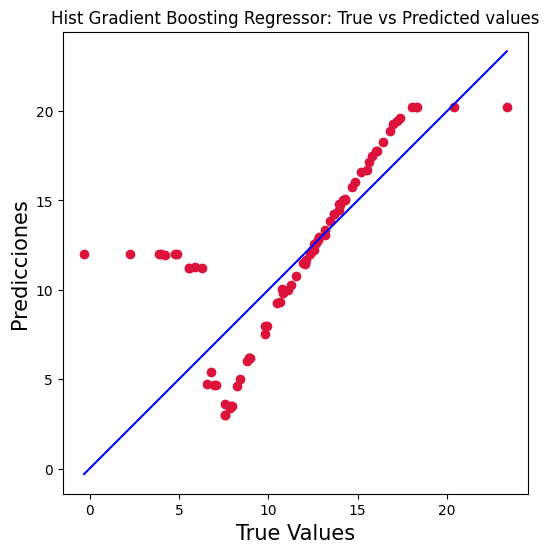

In [576]:
plot_true_vs_predicted(best_hgb, X_test, y_test, title="Hist Gradient Boosting Regressor: True vs Predicted values")

***Residual Plot***

En el siguiente gráfico se pueden observar los residuos que se obtuvieron para el modelo *HGB*.

$Residuo = predicción - valor\_real$

A mayor residuo, más alejados estarán los puntos azules del cero (línea recta con color rojo), lo cual indica una mala predicción en *test*.

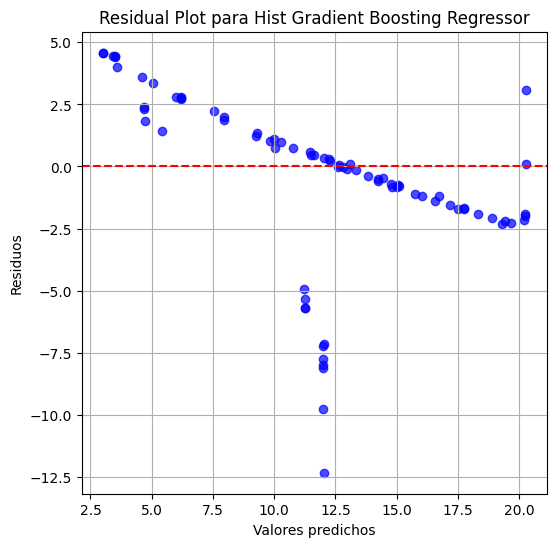

In [577]:
plot_residuals(best_hgb, X_test, y_test, title="Residual Plot para Hist Gradient Boosting Regressor")

### Paso 10.6 - XGBoost

***Descripción***

En este caso trabajamos con el modelo [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html) que nos permite aplicar *Gradient Boosting* para regresión.

A la hora de optimizar, nos basamos en los hiperparámetros recomendados en [este sitio](https://xgboosting.com/most-important-xgboost-hyperparameters-to-tune/):

- `max_depth`
    - Máxima altura/profundidad del árbol.
    - A mayor valor, el modelo será más complejo y más sensible a *overfitting*.
    - Estudiaremos los valores en el rango [$2$, $10$].
- `min_child_weight`
    - Suma mínima del peso de la instancia necesaria en un hijo.
    - Los valores más altos evitan *overfitting*.
    - Estudiaremos valores en el rango [$1$, $10$].
- `subsample`
    - Proporción de submuestras de las instancias de entrenamiento.
    - Los valores más bajos evitan *overfitting*.
    - Estudiaremos valores en el rango [$0.6$, $1.0$], con saltos de a $0.05$.
- `colsample_bytree`
    - Proporción de submuestras de columnas al construir cada árbol.
    - Los valores más bajos evitan *overfitting*.
    - Estudiaremos valores en el rango [$0.2$, $1.0$], con saltos de a $0.1$.
- `learning_rate`
    - Shrinkage utilizado en cada paso, para prevenir *overfitting*.
    - Los valores más bajos hacen que el modelo sea más robusto frente al *overfitting*.
    - Estudiaremos los valores [$0.001$, $0.003$, $0.005$, $0.01$, $0.03$, $0.05$, $0.1$].
- `reg_alpha`
    - Regularización $L1$.
    - Estudiaremos los valores [$0$, $0.1$, $0.5$, $1$, $5$, $10$].
- `reg_lambda`
    - Regularización $L2$.
    - Estudiaremos los valores [$0$, $0.1$, $0.5$, $1$, $5$, $10$].
- `n_estimators`
    - Cantidad de estimadores/árboles que utilizará el modelo.
    - Por lo general, a mayor cantidad, mejor performance, pero a su vez aumenta la cantidad de memoria y tiempo de entrenamiento requeridos.
    - Estudiaremos los valores del rango [$100$, $1000$], con saltos de a $100$.

La búsqueda de hiperparámetros se realizará mediante el framework [optuna](https://optuna.readthedocs.io/en/stable/index.html), en particular, con 100 iteraciones/trials.

En cada una de estas iteraciones, se utilizará la cross validation con $5$ splits mediante [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html), y se buscará minimizar el error cuadrático medio, utilizando la métrica [neg_root_mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html#sklearn.metrics.root_mean_squared_error) de Scikit learn.

***Resultados***

Estos son los mejores hiperparámetros que se obtuvieron mediante el framework *optuna*.

- *max_depth*: `10`,
- *min_child_weight*: `1`,
- *subsample*: `0.65`,
- *colsample_bytree*: `1.0`,
- *learning_rate*: `0.05`,
- *reg_alpha*: `1`,
- *reg_lambda*: `0`,
- *n_estimators*: `700`

El modelo `XGBoost` obtuvo las siguientes métricas al entrenarse y evaluarse en nuestros dataset de *train* y *test*, con los mejores hiperparámetros:

- *RMSE* en cross validation: $0.860901$
- *MAE* en test: $2.221381$
- *RMSE* en test: $3.111064$
- *R2* en test: $0.522103$			

***Conclusiones para XGBoost***

- El modelo ajustó bien en el dataset de *train* (*RMSE* de $0.860901$ para cross validation), pero no sucedió lo mismo en *test* (*RMSE* de $3.111064$), en donde el *RMSE* es cuatro veces superior. Esto indica que el modelo hace *overfitting*.
- En cuanto a la métrica de *R2*, el modelo obtuvo en *test* $0.522103$, es decir, captura aproximadamente el $52\%$ de la variabilidad de los datos.
- Se realizó el gráfico de *Valores reales vs predichos* y el *gráfico de residuos*, y en ambos se puede observar que el modelo presenta *overfitting*.
- Al comparar la performance (según *RMSE* en *test*) de este modelo con los anteriores para el dataset de *body_fat*, podemos observar que es mejor que *SVR* y *KNN*, que tiene un rendimiento cercano a *HistGradientBoostingRegressor* y a *Decision Tree*, y que *performa peor* que *Random Forest*.

Estos resultados pueden deberse a diversas razones:

- La principal razón es el tamaño del dataset, el cual cuenta con *252 registros* (*train* con $176$, y *test* con $76$) y *19 columnas*, lo cual no sería suficiente información para que el modelo capte relaciones (principalmente por la cantidad de registros).
- Esto a su vez hace que durante la optimización de hiperparámetros se utilicen valores poco óptimos:
    - Árboles con mucha produndidad (*max_depth* igual a $10$), lo cual genera poco *sesgo* (*underfit*) y mucha *varianza* (*overfit*).
    - Cantidad de estimadores utilizada
        - En los algoritmos de *boosting*, cada estimador/árbol trabaja (secuencialmente) sobre los errores del estimador/árbol anterior. 
        - En nuestro caso, como los estimadores tienen alta profundidad, su error será mayor.
        - Esto podría causar que el modelo en general requiera más estimadores.
        - Pero tener muchos estimadores puede causar problemas de *overfitting*.
        - En particular, la optimización arrojó "mejores" resultados en *train* con $700$ estimadores.
    - El mejor valor de *min_child_weight* (acorde a la optimización de hiperparámetros) es $1$, el menor que hemos definido en la búsqueda, y esto puede llevar a que el modelo produzca *overfitting*.
    <!-- - Un alto valor de *subsample* ($0.95$) según la optimización, siendo que valores más bajos ayudan a prevenir *overfitting*. -->
    - El mejor valor encontrado para *colsample_bytree* es uno de los más altos del rango definido para la búsqueda ($1$), cuando valores más bajos podrían ayudar a prevenir *overfitting*.
    - Relativamente baja regularización $L1$ (*reg_alpha* igual a $1$), lo cual puede generar *overfitting* (mas detalles [aquí](https://xgboosting.com/configure-xgboost-reg_alpha-parameter/)).
    - Nula regularización $L2$ (*reg_lambda* igual a $0$), lo cual puede generar *overfitting* (mas detalles [aquí](https://xgboosting.com/configure-xgboost-reg_lambda-parameter/)).

En conclusión, si bien `XGBoost` es uno de los mejores modelos que existen para trabajar sobre datos tabulares, en este dataset no tiene buena performance, lo cual se debe a la poca información (*252 registros*) que este presenta.

In [578]:
from xgboost import XGBRegressor

# Función objetivo para XGBoost, necesaria para trabajar con optuna.
def objective_XGBoost(trial):
    max_depth = trial.suggest_int("max_depth", 2, 10, step=1)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10, step=1)
    subsample = trial.suggest_float("subsample", 0.6, 1.0, step=0.05)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.2, 1.0, step=0.1)
    learning_rate = trial.suggest_categorical("learning_rate", [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1])
    reg_alpha = trial.suggest_categorical("reg_alpha", [0, 0.1, 0.5, 1, 5, 10])
    reg_lambda = trial.suggest_categorical("reg_lambda", [0, 0.1, 0.5, 1, 5, 10])
    n_estimators = trial.suggest_int("n_estimators", 100, 1000, step=100)
    
    xgb_model = XGBRegressor(random_state=random_state,
                             max_depth=max_depth,
                             min_child_weight=min_child_weight,
                             subsample=subsample,
                             colsample_bytree=colsample_bytree,
                             learning_rate=learning_rate,
                             reg_alpha=reg_alpha,
                             reg_lambda=reg_lambda,
                             n_estimators=n_estimators,
                             tree_method="hist",
                             n_jobs=-1)
    
    score = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
    
    # Como utilizamos `neg_root_mean_squared_error`, multiplicamos por -1
    # More info: https://datascience.stackexchange.com/a/93534
    return score.mean() * (-1)

In [579]:
optuna.logging.set_verbosity(optuna.logging.ERROR)

xgb_study = optuna.create_study(direction="minimize")
xgb_study.optimize(objective_XGBoost, n_trials=100, callbacks=[champion_callback])
best_xgb, best_xgb_params = optuna_eval_and_store("XGB-optuna", XGBRegressor, xgb_study, X_train, y_train, X_test, y_test)

Initial trial 0 achieved value: 1.188348898101555
Trial 6 achieved value: 1.1663343590149462 with  1.8875% improvement
Trial 8 achieved value: 1.007304101351435 with  15.7877% improvement
Trial 12 achieved value: 0.938483310246459 with  7.3332% improvement
Trial 16 achieved value: 0.9108709572797424 with  3.0314% improvement
Trial 32 achieved value: 0.8844261443176216 with  2.9901% improvement
Trial 68 achieved value: 0.8841572865190075 with  0.0304% improvement
Trial 70 achieved value: 0.8841526050169961 with  0.0005% improvement
Trial 76 achieved value: 0.8836752328397532 with  0.0540% improvement
Trial 77 achieved value: 0.8609012735324445 with  2.6454% improvement


,modelo,mejor_params,cv_RMSE,test_MAE,test_RMSE,test_R2
0,RF-optuna,"{'n_estimators': 500, 'criterion': 'absolute_e...",0.936206,1.729450,2.119003,0.778293
1,XGB-optuna,"{'max_depth': 10, 'min_child_weight': 1, 'subs...",0.860901,2.221381,3.111064,0.522103
2,HGB-optuna,"{'loss': 'absolute_error', 'learning_rate': 0....",0.730105,2.474978,3.507054,0.392703
3,Decision-Tree-optuna,"{'max_depth': None, 'min_samples_split': 5, 'm...",1.173618,2.696183,3.658622,0.339077
4,SVR-optuna,"{'kernel': 'rbf', 'gamma': 0.00999197949182039...",0.731850,3.689215,4.584282,-0.037669
5,KNN,"{'n_neighbors': 5, 'p': 2, 'weights': 'distance'}",2.471977,3.747122,4.706763,-0.093858


***True vs Predicted values***

En el siguiente gráfico se puede observar el valor predicho por el modelo *XGBoost* para cada observación de *X_test*.

Estos valores son comparados con las medidas reales (*y_test*).

Se grafica en azul la función identidad ($y=x$), que representaría el caso en donde el valor predicho coincide con el valor real.

Los puntos rojos ubicados fuera de dicha recta representan medicione erróneas.

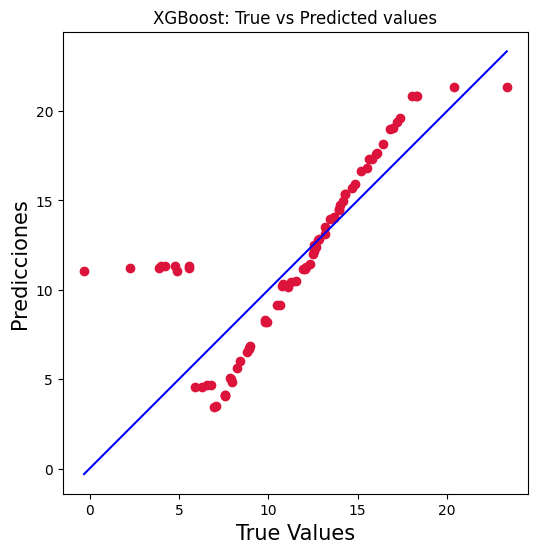

In [580]:
plot_true_vs_predicted(best_xgb, X_test, y_test, title="XGBoost: True vs Predicted values")

***Residual Plot***

En el siguiente gráfico se pueden observar los residuos que se obtuvieron para el modelo *XGBoost*.

$Residuo = predicción - valor\_real$

A mayor residuo, más alejados estarán los puntos azules del cero (línea recta con color rojo), lo cual indica una mala predicción en *test*.

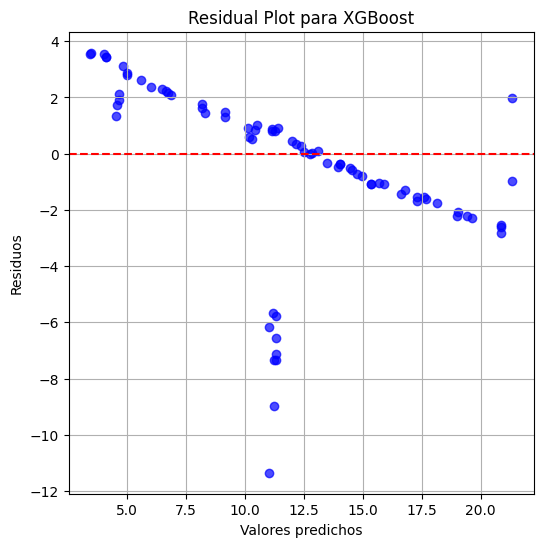

In [581]:
plot_residuals(best_xgb, X_test, y_test, title="Residual Plot para XGBoost")

## Conclusiones finales

En este trabajo se analizó el dataset de `Body fat prediction` dataset, el cual tiene *252 registros* y *20 columnas*.

En particular, se estudiaron técnicas de regresión sobre la variable `BodyFat`, y se llegó a la conclusión de que el modelo que mejor explica esta variable es el modelo de *Random Forest*, el cual se implementó mediante [RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html).

Si bien se estudiaron modelos "más complejos" basados en boosting (como *XGBoost* y *HistGradientBoostingRegressor*) que por lo general son lo que mejor performan en datos tabulares, la poca cantidad de datos presentes (*252* registros totales, con 176 para *train* y 76 para *test*) afecta negativamente su rendimiento.

Por su parte, *Random Forest* se ve beneficiado por su arquitectura y los hiperparámetros obtenidos al implementar busqueda bayesiana (mediante *optuna*):
- Para nuestro caso de estudio, obtuvimos un modelo cuyos árboles tienen como máximo una profundidad de $30$ y un total de $500$ estimadores, entre otros parámetros.
- Esto hace que cada árbol tenga una varianza alta, es decir, que genere *overfitting*.
- Pero como la varianza total del modelo se calcula como el promedio de la varianza de cada árbol, y en total tenemos $500$ estimadores, ésta se termina *reduciendo*, logrando de esta manera capturar un porcentaje alto de la variabilidad total de los pocos datos que tenemos (en particular, el $77\%$ de los datos de *test*).

Por último, detallamos las distintas operaciones que se realizaron sobre el dataset de `Body Fat prediction`, las cuales incidieron en el resultado final:

1. Se realizó un análisis exploratorio del dataset, a fin de conocer los tipos y distribuciones de cada columna.
1. Se dividió el dataset en *train* (*176* filas) y *test* (*76* filas). Se define a la columna `BodyFat` como *target* de regresión.
1. Se encontró un registro en *train* con el valor de `BodyFat` en cero. Se lo trató como nulo, imputándolo con la *mediana* de esta variable en *train*.
1. Se trataron los outliers de *train* y *test* de todas las columnas (incluyendo el *target*) mediante *Box-cox*.
1. Se creó la variable `BMI` o índice de masa corporal, combinando las variables `Weight` y `Height`.
1. Se discretizó a la variable `BMI`, creando `BMI_cat`. Además, se decidió dejar ambas variables en los datasets, a fin que cada modelo decida si es conveniente usarlas o no.
1. Se codificó la variable `BMI_cat` mediante *One-hot encoding*, creando $4$ variables nuevas (una por cada categoría de `BMI_cat`). Se borró del dataset la variable `BMI_cat`.
1. Se normalizaron todas las features del dataset mediante *Z-score*.
1. Se estudió reducir la dimensión del dataset mediante `PCA`, pero como este método implicaría reducir un dataset relativamente pequeño a la mitad de sus columnas, optamos por no aplicarlo.
1. Finalmente, se estudiaron diversos modelos, concluyendo que *Random Forest* es el que mejor explica estos datos.